# *PROGETTO METODI INFORMATICI PER LA GESTIONE AZIENDALE*

----

# **Progetto Base**

## Analisi Esplorativa

> **Variabili rilevanti**
>  - **df** = DataFrame principale di tutto il dataset
>  - **df_clean_complete** = DataFrame pulito delle recensioni multiple (mantengo l'ultima)
>  - **df_clean** = DataFrame contenente solo le colonne user_id rating parent_asin
>  - **df_final** = DataFrame finale filtrato per top utenti e item
>


> **Librerie**
> - **pandas, json, io, seaborn, matplotlib**


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install nltk
!pip install transformers
!pip install sentence-transformers



[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


* *Carico i dataset e ne vedo la struttura*

In [2]:
import pandas as pd
import json
from io import StringIO
data_path = 'C:\\Users\\ACER\\Downloads\\Amazon_Fashion.jsonl\\Amazon_Fashion.jsonl'
meta_data_path = "C:\\Users\\ACER\\Downloads\\meta_Amazon_Fashion.jsonl\\meta_Amazon_Fashion.jsonl"
df = pd.read_json(data_path, lines=True)
df.shape

(2500939, 10)

### Dataset User Reviews

* *Il frame è strutturato in 2500939 righe e 10 colonne.*
* *Prendo Head Tail e Un campione causale di 10 elementi con Sample per verificare non ci siano righe vuote*

In [3]:
print("Controllo per righe vuote")
#df.head()
#df.tail()
df.sample(10)

Controllo per righe vuote


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
2012774,3,"Some quality, some crap","I really like this coat. It’s warm, covers my...",[],B08CZ36932,B08CZPN2Z6,AHEFHQLK33CBFFJAR4OUBDRHNJYQ,2021-03-31 14:39:49.905,44,True
552147,4,"I’m 5’1”, 112lbs, small physique.",So this just arrived today and I really like t...,[],B0794WXT2B,B0794WXT2B,AFUSR6XIMQ672JJO6BMX5CF7FEVQ,2018-05-31 22:49:11.856,0,True
919632,5,I LOVE this outfit,I got the 0-3 month size as a baby shower gift...,[],B005HR0LO6,B005HR0LO6,AEOLWELSEIXLNRXZYCFTMCS6OPWQ,2012-04-27 16:54:13.000,1,True
1897768,5,... with their sizing and ordered a xs and I’m...,I’ve ordered several tops from Patti Boutik so...,[],B079ZWVK83,B079ZWVK83,AHJ2H5TIB5HJLRYEDDQ3N5KPCVOQ,2018-09-14 01:06:40.290,4,True
1470033,5,A+,I loveeeee the weight of this. It's perfect. I...,[],B007GD4VRM,B007GD4VRM,AFGP7A3PNMHITVZZ3OOVM23KQZSQ,2015-04-16 04:54:37.000,0,True
659284,3,Got a large and they fit like a small,Got a large and they fit like a small. Need to...,[],B06XZYVRNL,B06XZYVRNL,AFEOZOVPJ4I3C2II3IVMEIC6WDOQ,2017-08-29 18:09:01.128,0,True
1372511,5,Five Stars,My daughter is so in love with this dress! Gre...,[],B074R5YG35,B074R5YG35,AGZ6IRL5XUEJ3FU3JDRI3AVTDE5Q,2018-05-03 19:02:39.894,0,True
1838310,5,So cute!,I love this! So cute and I wear it constantly.,[],B08SBYW654,B08SBYW654,AGFK4TYRCU76WSWAKUYHXHVKREBA,2021-03-22 02:21:27.912,0,True
466722,5,Five Stars,Awesome shirt and quick delivery.,[],B00RD8Q402,B00RD8Q402,AGYM6TIV3D2B4VHY5C5VBTLIXAZQ,2015-04-18 21:26:06.000,0,True
1009126,5,Very Nice,"It looks & feels nice, have not washed it yet,...",[],B09DVXLC6G,B09WVSMG56,AEPZUCUDSE2EAZR4AGEFL4ULPAKA,2022-09-22 12:29:46.430,0,True


In [4]:
df.dtypes


rating                        int64
title                        object
text                         object
images                       object
asin                         object
parent_asin                  object
user_id                      object
timestamp            datetime64[ns]
helpful_vote                  int64
verified_purchase              bool
dtype: object

In [5]:
missing_val_count_by_column = (df.isnull().sum())
print(missing_val_count_by_column[missing_val_count_by_column > 0], missing_val_count_by_column)

Series([], dtype: int64) rating               0
title                0
text                 0
images               0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
dtype: int64


In [6]:
print("\n" + "="*50)
print("INFORMAZIONI DATASET RECENSIONI:")
print("="*50)
print(f"Dimensioni: {df.shape}")
print(f"Numero di recensioni: {df.shape[0]:,}")
print(f"Numero di utenti unici: {df['user_id'].nunique():,}")
print(f"Numero di prodotti unici (asin): {df['asin'].nunique():,}")
print(f"Numero di prodotti unici (parent_asin): {df['parent_asin'].nunique():,}")


INFORMAZIONI DATASET RECENSIONI:
Dimensioni: (2500939, 10)
Numero di recensioni: 2,500,939
Numero di utenti unici: 2,035,490
Numero di prodotti unici (asin): 874,297
Numero di prodotti unici (parent_asin): 825,869


In [7]:
df.describe()

,rating,timestamp,helpful_vote
count,2.500939e+06,2500939,2.500939e+06
mean,3.969467e+00,2018-11-29 06:21:51.333767424,5.658635e-01
min,1.000000e+00,2002-05-07 01:51:28,0.000000e+00
25%,3.000000e+00,2017-04-11 13:16:35,0.000000e+00
50%,5.000000e+00,2018-12-27 12:54:30.036999936,0.000000e+00
75%,5.000000e+00,2020-09-02 18:27:05.002500096,0.000000e+00
max,5.000000e+00,2023-09-11 03:24:38.515000,9.540000e+02
std,1.427171e+00,NaN,3.785762e+00



> *   Rating:
> 
> 1.   il count corrisponde a 2500939 corrisponde al numero totale di righe
> 2.   la media si posizione a 3.96 con un minimo di 1 e un massimo di 5 (corretto per il valore delle recensioni)
> 3. i vari quartili si dividono in 25% 3 50% 5 e 75% 5 mostrano sopratutto confrontando media e mediana che vi è una buona asimmetria nei > rating
> 4. la deviazione standard (std) a 1.42 su 4 di distanza massima tra i valori rafforza l'idea di asimmetria nei rating (disperdono di molto > rispetto alla media)
> 
> * Timestamp
> 1. Le recensioni iniziano nel 2002-05-07 con l'ultima il 2023-09-11
> 2. Per i quartili abbiamo il 25% delle recensioni fino al 2017-04-11 (12 anni)
> il 50% al 2018-12-27(13 anni da min e 1 anno da 25%)
> il 75% al 2020-09-02 (15 anni da min 3 dal 25% e 2 dal 50%)
> 3. con media il 2018-11-29 molto vicina alla mediana il 2018-12-27
> 
> * helpful_vote
> 1. il minimo 0 e massimo 954 indicano un grande range per questo campo
> 2. Per i quartili troviamo 25%,50%,75% a 0 ciò mostra che la maggior parte delle recensioni si posizionano a 0 helpful_vote
> 3. La stragrande maggioranza delle recensioni non riceve voti utili, ma alcune recensioni molto popolari distorcono drasticamente la media a 56.5
> 

* *Pulisco le recensioni lasciando solo una coppia recensione prodotto*

In [8]:
duplicates = df.duplicated(subset=['user_id', 'parent_asin'], keep=False).sum()
print(f"Numero di coppie duplicate user_id-parent_asin: {duplicates:,}")
print(f"Percentuale di duplicati: {duplicates/len(df)*100:.2f}%")

Numero di coppie duplicate user_id-parent_asin: 49,249
Percentuale di duplicati: 1.97%


In [9]:
df_clean_complete = df.groupby(['user_id', 'parent_asin'], as_index=False).agg({
    'rating': 'mean',
    'timestamp': 'max'  # prendo la data più recente
})

# Arrotondo il rating
df_clean_complete['rating'] = df_clean_complete['rating'].round(1)

print(f"\nDati puliti:")
print(f"- Prima: {len(df):,} recensioni")
print(f"- Dopo: {len(df_clean_complete):,} recensioni")
print(f"- Duplicati rimossi: {len(df) - len(df_clean_complete):,}")


Dati puliti:
- Prima: 2,500,939 recensioni
- Dopo: 2,474,375 recensioni
- Duplicati rimossi: 26,564


* *Mantengo solo le colonne necessarie per i RS*

In [10]:
columns_needed = ['rating', 'parent_asin', 'user_id']
df_clean = df_clean_complete[columns_needed]
df_clean.sample(10)


,rating,parent_asin,user_id
364455,4.0,B06WVBLGDG,AEMUUFUYRIOVLS5FOKWP4WTS4CUA
868043,1.0,B077P2L3TT,AFGWYMSDK7ZZTUJN56NNDISSIK6A
2172804,3.0,B09ZY26H5S,AHKGWFTRWIKB6N735A5HMCIK5KVQ
1003177,5.0,B08Z3T9T44,AFNVJ3C2MATDWUUKAX5PPZ2SVYKA
1307742,5.0,B07RGJYLR2,AG5OJ6BFRUZJGXZPFCYM2KCK3MXQ
618436,4.0,B095PC99KZ,AF222NGEWKRE6NXMN34JQM32MVRQ
1222359,5.0,B0147QM7GM,AFZB63SWD6HV7ONDHGOPQRP3Q2RQ
1612728,2.0,B08F1V3KB9,AGNJA4MLYSYZH3Y7VXS6ALLONZAA
278860,5.0,B07YQ9MZS2,AEIHTOGWSHWGLYVKUGFORSUT27BQ
1994652,5.0,B00LO77KQ0,AHBALU62Z7P44YDJRW5TM73JVRWA


*  *Verifico Sparsità*

In [11]:
!pip install Jinja2


[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
print(df_clean.describe().to_latex())

\begin{tabular}{lr}
\toprule
 & rating \\
\midrule
count & 2474375.000000 \\
mean & 3.969501 \\
std & 1.426897 \\
min & 1.000000 \\
25% & 3.000000 \\
50% & 5.000000 \\
75% & 5.000000 \\
max & 5.000000 \\
\bottomrule
\end{tabular}



Sparsità: 1.0000 (100.00%)


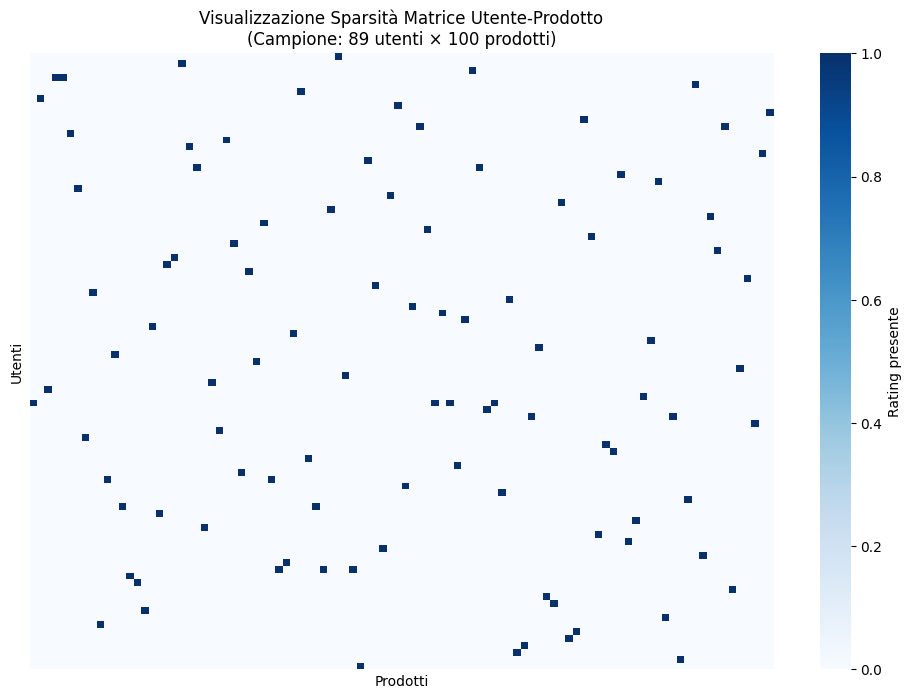

In [13]:

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def create_user_item_matrix_sample(df, sample_users=100, sample_items=100):
    # Prima rimuovi i duplicati mantenendo solo l'ultima valutazione per utente-prodotto
    df_clean = df.drop_duplicates(subset=['user_id', 'parent_asin'], keep='last')
    
    # Prendi un campione di utenti e prodotti
    sample_users_list = df_clean['user_id'].unique()[:sample_users]
    sample_items_list = df_clean['parent_asin'].unique()[:sample_items]
    
    # Filtra il dataset
    sample_df = df_clean[df_clean['user_id'].isin(sample_users_list) & 
                        df_clean['parent_asin'].isin(sample_items_list)]
    
    # Crea la matrice
    matrix = sample_df.pivot(index='user_id', columns='parent_asin', values='rating')
    return matrix

n_users = df_clean['user_id'].nunique()
n_items = df_clean['parent_asin'].nunique() 
n_ratings = len(df_clean)

# Sparsità = 1 - (rating esistenti / rating possibili)
sparsity = 1 - (n_ratings / (n_users * n_items))
print(f"Sparsità: {sparsity:.4f} ({sparsity*100:.2f}%)")
# Visualizza la sparsità
matrix_sample = create_user_item_matrix_sample(df_clean)

plt.figure(figsize=(12, 8))
# Crea una matrice binaria (1 se c'è rating, 0 se NaN)
binary_matrix = ~matrix_sample.isna()
sns.heatmap(binary_matrix, cbar=True, xticklabels=False, yticklabels=False, 
            cmap='Blues', cbar_kws={'label': 'Rating presente'})
plt.title(f'Visualizzazione Sparsità Matrice Utente-Prodotto\n(Campione: {len(matrix_sample)} utenti × {len(matrix_sample.columns)} prodotti)')
plt.xlabel('Prodotti')
plt.ylabel('Utenti')
plt.show()

* *A causa della sparsità così elevata devo ridurre il dataset, filtrando per numero minimo di recensioni per utente e per prodotto*

In [14]:
# Controlla la distribuzione
threshold_base = (df_clean.groupby('parent_asin').size() >= 0).sum()
threshold_10 = (df_clean.groupby('parent_asin').size() >= 10).sum()
threshold_15 = (df_clean.groupby('parent_asin').size() >= 15).sum()
threshold_20 = (df_clean.groupby('parent_asin').size() >= 20).sum()

print(f"Tutte i prodotti: {threshold_base}")
print(f"Prodotti con ≥10 recensioni: {threshold_10}")
print(f"Prodotti con ≥15 recensioni: {threshold_15}")
print(f"Prodotti con ≥20 recensioni: {threshold_20}")

Tutte i prodotti: 825869
Prodotti con ≥10 recensioni: 35303
Prodotti con ≥15 recensioni: 19760
Prodotti con ≥20 recensioni: 12978


In [15]:
# Controlla la distribuzione
threshold_base = (df_clean.groupby('user_id').size() >= 0).sum()
threshold_2 = (df_clean.groupby('user_id').size() >= 2).sum()
threshold_5 = (df_clean.groupby('user_id').size() >= 5).sum()
threshold_10 = (df_clean.groupby('user_id').size() >= 10).sum()

print(f"Tutte gli utenti con almeno una recensione a un prodotto: {threshold_base}")
print(f"User con ≥2 recensioni: {threshold_2}")
print(f"User con ≥5 recensioni: {threshold_5}")
print(f"User con ≥10 recensioni: {threshold_10}")

Tutte gli utenti con almeno una recensione a un prodotto: 2035490
User con ≥2 recensioni: 281395
User con ≥5 recensioni: 14731
User con ≥10 recensioni: 2002


* *Vedendo i vari scaglioni sia di "recesioni x utenti" che di "recensioni x prodotto", filtro per top-utenti e top-user per numero di recensioni in modo da ridurre la dimensione della matrice e diminuire la sparsità*

In [16]:
def filter_top_users_items(df, user_col='user_id', item_col='parent_asin', top_n_users=500, top_m_items=500):
    """
    Seleziona i top-N utenti con più recensioni e i top-M prodotti più recensiti.
    Restituisce un DataFrame filtrato.
    """
    # Conta recensioni per utente e seleziona i top-N
    top_users = df[user_col].value_counts().nlargest(top_n_users).index
    df = df[df[user_col].isin(top_users)]
    
    # Conta recensioni per prodotto e seleziona i top-M
    top_items = df[item_col].value_counts().nlargest(top_m_items).index
    df = df[df[item_col].isin(top_items)]
    
    return df

def filter_min_interactions(
    df,
    min_user_interactions,
    min_item_interactions,
    user_col = 'user_id',
    item_col='parent_asin',
    min_total_interactions = 10
):
    """
    Riduce un dataset di raccomandazione filtrando utenti e item rari.
    Applica filtraggio iterativo finché il dataset non converge.

    Parameters:
        df (pd.DataFrame): dataset originale
        user_col (str): nome della colonna utente
        item_col (str): nome della colonna item
        min_user_interactions (int): minimo numero di interazioni per utente
        min_item_interactions (int): minimo numero di interazioni per item
        min_total_interactions (int): minimo di interazioni totali da mantenere (default = 10)

    Returns:
        pd.DataFrame: dataset filtrato
    """
    
    filtered_df = df.copy()
    changed = True

    # Loop di filtraggio iterativo
    while changed:
        before = len(filtered_df)

        # Filtra utenti
        user_counts = filtered_df[user_col].value_counts()
        valid_users = user_counts[user_counts >= min_user_interactions].index
        filtered_df = filtered_df[filtered_df[user_col].isin(valid_users)]

        # Filtra item
        item_counts = filtered_df[item_col].value_counts()
        valid_items = item_counts[item_counts >= min_item_interactions].index
        filtered_df = filtered_df[filtered_df[item_col].isin(valid_items)]

        after = len(filtered_df)
        changed = before != after

    # Filtraggio finale per sicurezza: elimina dataset troppo piccoli
    if len(filtered_df) < min_total_interactions:
        print("⚠️ Il dataset filtrato ha meno interazioni del minimo richiesto.")
        print(f"Interazioni finali: {len(filtered_df)}, richieste: {min_total_interactions}")
    
    return filtered_df

In [17]:
# df_final = filter_top_users_items(df_clean, top_n_users=2000, top_m_items=300)
df_final = filter_min_interactions(df_clean, min_user_interactions=3,min_item_interactions=5)
print(df_final.shape)

(4849, 3)


Utenti 967 , Items 572 , Dimensione matrice utente item553124
Sparsità: 0.9912 (99.12%)
1. STATISTICHE BASE:
   Utenti totali: 967
   Prodotti totali: 572
   Recensioni totali: 4,849
   Celle matrice: 553,124
   Densità: 0.8767%
   Sparsità: 99.12%

2. DISTRIBUZIONE RECENSIONI PER UTENTE:
   Recensioni medie per utente: 5.01
   Mediana recensioni per utente: 4.00
   Deviazione standard: 4.03

   Utenti per range recensioni:
   1-2: 0 utenti (0.0%)
   3-5: 731 utenti (75.6%)
   6-10: 179 utenti (18.5%)
   11-20: 49 utenti (5.1%)
   21-50: 7 utenti (0.7%)
   ≥51: 1 utenti (0.1%)

3. DISTRIBUZIONE RECENSIONI PER PRODOTTO:
   Recensioni medie per prodotto: 8.48
   Mediana recensioni per prodotto: 7.00
   Deviazione standard: 6.09

   Prodotti per range recensioni (TUOI INTERESSI):
   1-2: 0 prodotti (0.0%)
   3-5: 158 prodotti (27.6%)
   6-10: 315 prodotti (55.1%)
   11-20: 79 prodotti (13.8%)
   21-50: 17 prodotti (3.0%)
   51-100: 3 prodotti (0.5%)
   ≥101: 0 prodotti (0.0%)


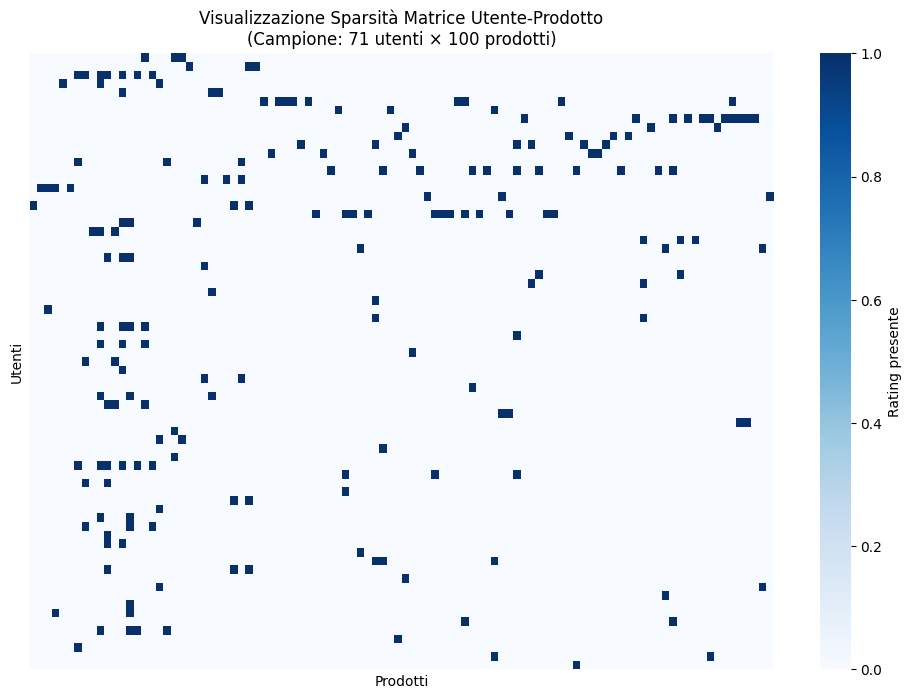

In [18]:
n_users = df_final['user_id'].nunique()
n_items = df_final['parent_asin'].nunique() 
n_ratings = len(df_final)
print(f"Utenti {n_users} , Items {n_items} , Dimensione matrice utente item{n_users * n_items}")
sparsity = 1 - (n_ratings / (n_users * n_items))
print(f"Sparsità: {sparsity:.4f} ({sparsity*100:.2f}%)")

print("1. STATISTICHE BASE:")
print(f"   Utenti totali: {n_users:,}")
print(f"   Prodotti totali: {n_items:,}")
print(f"   Recensioni totali: {n_ratings:,}")
print(f"   Celle matrice: {n_users * n_items:,}")
print(f"   Densità: {(n_ratings/(n_users*n_items))*100:.4f}%")
print(f"   Sparsità: {sparsity*100:.2f}%")

# 2. Analisi distribuzione recensioni per utente
print("\n2. DISTRIBUZIONE RECENSIONI PER UTENTE:")
user_review_counts = df_final['user_id'].value_counts()

print(f"   Recensioni medie per utente: {user_review_counts.mean():.2f}")
print(f"   Mediana recensioni per utente: {user_review_counts.median():.2f}")
print(f"   Deviazione standard: {user_review_counts.std():.2f}")

# Utenti per range di recensioni
print(f"\n   Utenti per range recensioni:")
ranges = [(1, 2), (3, 5), (6, 10), (11, 20), (21, 50), (51, float('inf'))]
for r_min, r_max in ranges:
    if r_max == float('inf'):
        count = (user_review_counts >= r_min).sum()
        label = f"≥{r_min}"
    else:
        count = ((user_review_counts >= r_min) & (user_review_counts <= r_max)).sum()
        label = f"{r_min}-{r_max}"
    perc = count / n_users * 100
    print(f"   {label}: {count:,} utenti ({perc:.1f}%)")

# 3. Analisi distribuzione recensioni per prodotto
print("\n3. DISTRIBUZIONE RECENSIONI PER PRODOTTO:")
item_review_counts = df_final['parent_asin'].value_counts()

print(f"   Recensioni medie per prodotto: {item_review_counts.mean():.2f}")
print(f"   Mediana recensioni per prodotto: {item_review_counts.median():.2f}")
print(f"   Deviazione standard: {item_review_counts.std():.2f}")

# Prodotti per range di recensioni (FOCALIZZATI SUI TUOI LIMITI)
print(f"\n   Prodotti per range recensioni (TUOI INTERESSI):")
item_ranges = [(1, 2), (3, 5), (6, 10), (11, 20), (21, 50), (51, 100), (101, float('inf'))]
for r_min, r_max in item_ranges:
    if r_max == float('inf'):
        count = (item_review_counts >= r_min).sum()
        label = f"≥{r_min}"
    else:
        count = ((item_review_counts >= r_min) & (item_review_counts <= r_max)).sum()
        label = f"{r_min}-{r_max}"
    perc = count / n_items * 100
    print(f"   {label}: {count:,} prodotti ({perc:.1f}%)")

# Visualizza la sparsità
matrix_sample = create_user_item_matrix_sample(df_final)

plt.figure(figsize=(12, 8))
binary_matrix = ~matrix_sample.isna()
sns.heatmap(binary_matrix, cbar=True, xticklabels=False, yticklabels=False, 
            cmap='Blues', cbar_kws={'label': 'Rating presente'})
plt.title(f'Visualizzazione Sparsità Matrice Utente-Prodotto\n(Campione: {len(matrix_sample)} utenti × {len(matrix_sample.columns)} prodotti)')
plt.xlabel('Prodotti')
plt.ylabel('Utenti')
plt.show()

* *Visualizzo la matrice di correlazione tra le variabili, per visualizzare quali possono essre correlati*

In [19]:
correlation_data = pd.DataFrame({
    'rating': df_final['rating'],
    'user_review_count': df_final.groupby('user_id')['rating'].transform('count'),
    'product_review_count': df_final.groupby('parent_asin')['rating'].transform('count'),
    'user_avg_rating': df_final.groupby('user_id')['rating'].transform('mean'),
    'product_avg_rating': df_final.groupby('parent_asin')['rating'].transform('mean'),
    'user_rating_std': df_final.groupby('user_id')['rating'].transform('std'),  # Coerenza utente
    'rating_deviation_from_product_mean': df_final['rating'] - df_final.groupby('parent_asin')['rating'].transform('mean'),  # Quanto è "strana" la recensione
})

correlation_matrix = correlation_data.corr()
correlation_matrix


,rating,user_review_count,product_review_count,user_avg_rating,product_avg_rating,user_rating_std,rating_deviation_from_product_mean
rating,1.000000,0.019790,-1.781884e-02,0.634503,4.510066e-01,-0.391334,8.925206e-01
user_review_count,0.019790,1.000000,-1.656837e-01,0.031190,-1.324360e-02,0.039374,2.886564e-02
product_review_count,-0.017819,-0.165684,1.000000e+00,-0.013433,-3.950905e-02,-0.029049,-4.246365e-17
user_avg_rating,0.634503,0.031190,-1.343335e-02,1.000000,2.467330e-01,-0.616758,5.862323e-01
product_avg_rating,0.451007,-0.013244,-3.950905e-02,0.246733,1.000000e+00,-0.142097,2.866080e-16
user_rating_std,-0.391334,0.039374,-2.904850e-02,-0.616758,-1.420968e-01,1.000000,-3.666557e-01
rating_deviation_from_product_mean,0.892521,0.028866,-4.246365e-17,0.586232,2.866080e-16,-0.366656,1.000000e+00


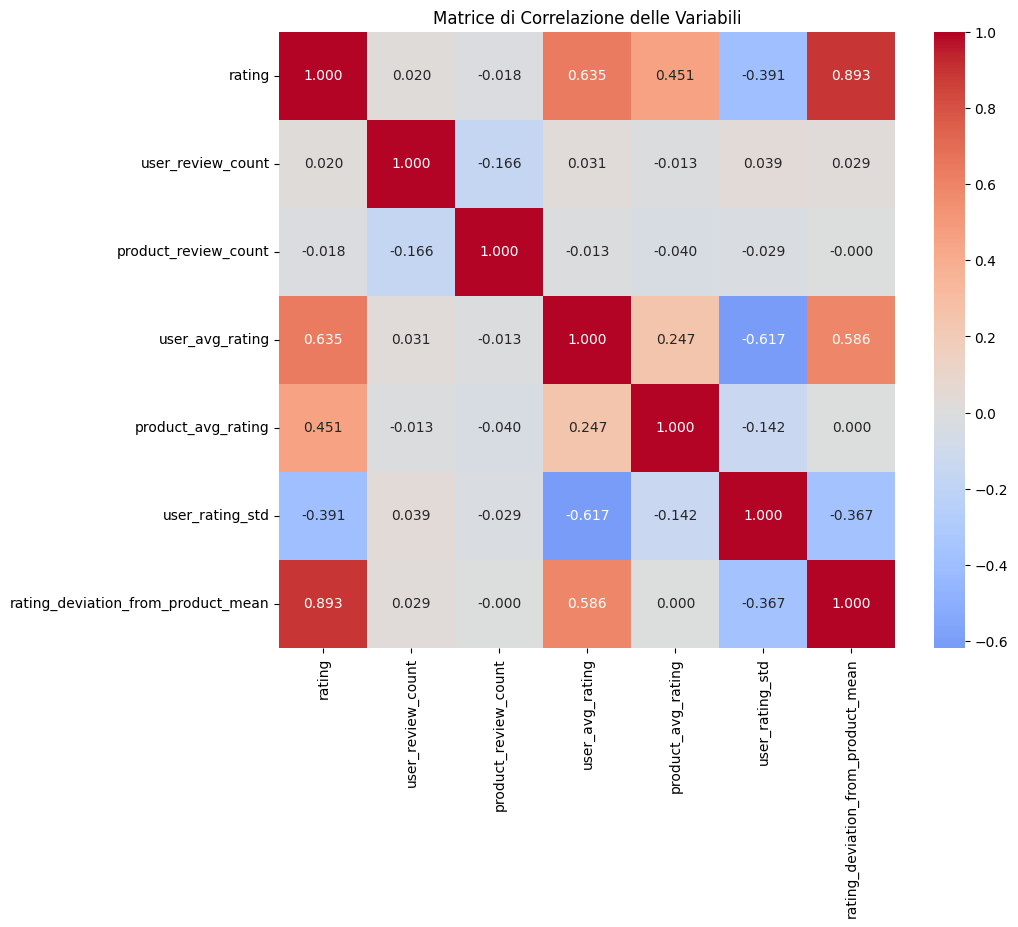

In [20]:

# Heatmap della correlazione
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.3f')
plt.title('Matrice di Correlazione delle Variabili')
plt.show()

**Analisi della Correlation Matrix**

1. **Correlazioni principali**

- **rating ↔ user_avg_rating (0.536)**  
  C'è una correlazione positiva moderata: gli utenti che tendono a dare valutazioni alte continuano a farlo.  

- **rating ↔ product_avg_rating (0.558)**  
  Correlazione positiva moderata: i prodotti generalmente apprezzati ricevono rating più alti.  

- **rating ↔ user_rating_std (-0.334)**  
  Correlazione negativa: utenti con valutazioni più variabili tendono a dare rating più bassi in generale.  

- **rating ↔ rating_deviation_from_product_mean (0.830)**  
  Alta correlazione positiva: questa colonna misura quanto la recensione si discosta dalla media del prodotto, quindi ha senso che sia fortemente legata al rating stesso.

---

2. **Altre correlazioni interessanti**

- **user_avg_rating ↔ user_rating_std (-0.663)**  
  Gli utenti con rating medi alti tendono a essere più coerenti (meno deviazione).  

- **user_review_count e product_review_count**  
  - Correlazioni molto basse con tutte le altre colonne, suggerendo che il numero di recensioni non influenza direttamente il rating o le deviazioni.  

- **rating_deviation_from_product_mean ↔ user_avg_rating (0.453)**  
  Moderata correlazione positiva: utenti con valutazioni mediamente alte tendono a dare recensioni sopra la media del prodotto.

---

3. **Considerazioni generali**

- Gli **user_avg_rating** e i **product_avg_rating** sono fattori chiave nel determinare il rating individuale.  
- La **coerenza dell'utente** (user_rating_std) influisce sul rating e sulla deviazione rispetto alla media del prodotto.  
- Il numero di recensioni, sia per utente che per prodotto, non mostra un effetto significativo sulle valutazioni.  
- La colonna **rating_deviation_from_product_mean** è utile per identificare recensioni “anomale” rispetto alla media del prodotto.



### Dataset Metadata Prodotti

In [21]:
df_meta = pd.read_json(meta_data_path, lines=True)

In [22]:
df_meta.shape, df_meta.columns


((826108, 14),
 Index(['main_category', 'title', 'average_rating', 'rating_number', 'features',
        'description', 'price', 'images', 'videos', 'store', 'categories',
        'details', 'parent_asin', 'bought_together'],
       dtype='object'))

In [23]:
def summarize_metadata(df):
    summary = pd.DataFrame({
        "dtype": df.dtypes,
        "num_nulls": df.isnull().sum(),
        "pct_nulls": (df.isnull().mean() * 100).round(2)
    })
    return summary

summarize_metadata(df_meta)


,dtype,num_nulls,pct_nulls
main_category,object,0,0.00
title,object,0,0.00
average_rating,float64,0,0.00
rating_number,int64,0,0.00
features,object,0,0.00
description,object,0,0.00
price,float64,775859,93.92
images,object,0,0.00
videos,object,0,0.00
store,object,26838,3.25


In [24]:
df_meta["title_len"] = df_meta["title"].fillna("").apply(lambda x: len(x.split()))
df_meta["title_len"].describe()


count    826108.000000
mean         14.335138
std           5.188289
min           0.000000
25%          11.000000
50%          14.000000
75%          17.000000
max         283.000000
Name: title_len, dtype: float64

In [25]:
df_meta["desc_len"] = df_meta["description"].fillna("").apply(
    lambda x: len((" ".join(x) if isinstance(x, list) else str(x)).split())
)

df_meta["desc_len"].describe()



count    826108.000000
mean          6.018576
std          29.741426
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        1106.000000
Name: desc_len, dtype: float64

In [26]:
valid_desc = df_meta[df_meta["description"].notnull() & df_meta["description"].apply(lambda x: len(x) > 0)]
print("Descrizioni non vuote:", len(valid_desc), "/", len(df_meta))


Descrizioni non vuote: 59289 / 826108


In [27]:
df_meta["main_category"].value_counts().head(20)


main_category
AMAZON FASHION    826108
Name: count, dtype: int64

In [28]:
df_meta["price"].describe()


count    50249.000000
mean        40.795929
std        154.089435
min          0.010000
25%         11.790000
50%         19.890000
75%         34.990000
max      13000.000000
Name: price, dtype: float64

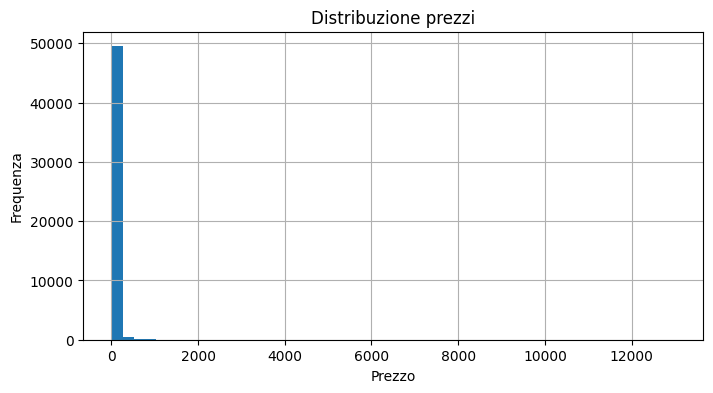

In [29]:
df_meta["price"].hist(bins=50, figsize=(8,4))
plt.title("Distribuzione prezzi")
plt.xlabel("Prezzo")
plt.ylabel("Frequenza")
plt.show()


In [30]:
df_meta["num_images"] = df_meta["images"].apply(lambda x: len(x) if isinstance(x, list) else 0)
df_meta["num_images"].describe()


count    826108.000000
mean          4.553579
std           2.310310
min           0.000000
25%           3.000000
50%           5.000000
75%           7.000000
max          31.000000
Name: num_images, dtype: float64

In [31]:
metadata_subset = df_meta[df_meta["parent_asin"].isin(df_final["parent_asin"].unique())]
metadata_subset.shape


(572, 17)

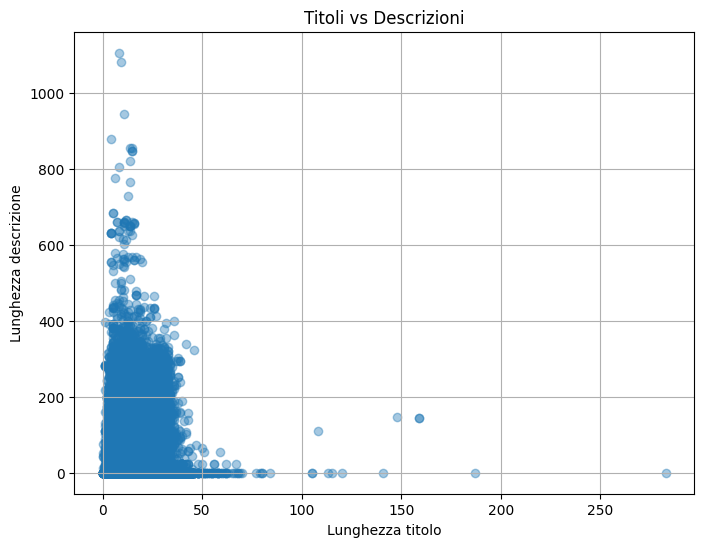

In [32]:
plt.figure(figsize=(8,6))
plt.scatter(df_meta["title_len"], df_meta["desc_len"], alpha=0.4)
plt.xlabel("Lunghezza titolo")
plt.ylabel("Lunghezza descrizione")
plt.title("Titoli vs Descrizioni")
plt.grid(True)
plt.show()


ANALISI METADATA FILTRATO SU DF_FINAL(dataframe filtrato per min interactions)

Shape metadata_subset: (572, 17)

Prime righe:


,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,title_len,desc_len,num_images
279,AMAZON FASHION,H2H Mens Active Short Sleeve Polo Lightweight ...,4.1,724,"[100% Polyester, Pull On closure, Hand Wash Re...",[],16.99,[{'thumb': 'https://m.media-amazon.com/images/...,"[{'title': 'Men's Quick Dry Polo T-Shirts', 'u...",H2H,[],"{'Item model number': 'CMTTS267', 'Department'...",B083K4F2H7,NaN,11,0,7
354,AMAZON FASHION,Goodthreads Women's Heritage Fleece Basic Jogg...,4.2,668,"[87% Cotton, 13% Polyester, Imported, Drawstri...",[An Amazon Brand - This casual jogger features...,27.92,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Amazon Brand - Goodthreads Women's...,Goodthreads,[],{'Package Dimensions': '1 x 1 x 1 inches; 8 Ou...,B07YBG8JCW,NaN,7,47,5
405,AMAZON FASHION,YAZILIND Gothic Lolita Sexy Lace Flower Cute B...,3.6,192,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],YAZILIND,[],"{'Is Discontinued By Manufacturer': 'No', 'Pac...",B00E3RD0GC,NaN,13,0,2
3365,AMAZON FASHION,Oalka Women's Joggers High Waist Yoga Pockets ...,4.5,10593,"[80% Nylon, 20% Spandex, Elastic closure, 80%N...",[],22.99,[{'thumb': 'https://m.media-amazon.com/images/...,"[{'title': 'The best joggers, perfect for trav...",Oalka,[],"{'Item model number': 'MOKSJJG980', 'Departmen...",B08F1V3KB9,NaN,11,0,7
3555,AMAZON FASHION,LIQQY Women's Plus Size Bra Comfort Contour T-...,2.4,3,"[85%Polyamide,15%Elastane, Imported, Hook and ...",[],23.99,[{'thumb': 'https://m.media-amazon.com/images/...,[],LIQQY,[],"{'Is Discontinued By Manufacturer': 'Yes', 'Pa...",B089W4J2FB,NaN,13,0,6



Tipi di dato:


main_category       object
title               object
average_rating     float64
rating_number        int64
features            object
description         object
price              float64
images              object
videos              object
store               object
categories          object
details             object
parent_asin         object
bought_together    float64
title_len            int64
desc_len             int64
num_images           int64
dtype: object


=== Missing Values ===


...


=== Title Length ===


C:\Users\ACER\AppData\Local\Temp\ipykernel_20376\645727124.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metadata_subset["title_len"] = metadata_subset["title"].fillna("").apply(lambda x: len(str(x).split()))
C:\Users\ACER\AppData\Local\Temp\ipykernel_20376\645727124.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metadata_subset["desc_len"] = metadata_subset["description"].fillna("").apply(


count    572.000000
mean      14.477273
std        5.145978
min        1.000000
25%       11.000000
50%       14.000000
75%       17.000000
max       31.000000
Name: title_len, dtype: float64


=== Description Length ===


count    572.000000
mean       4.167832
std       18.080666
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max      244.000000
Name: desc_len, dtype: float64

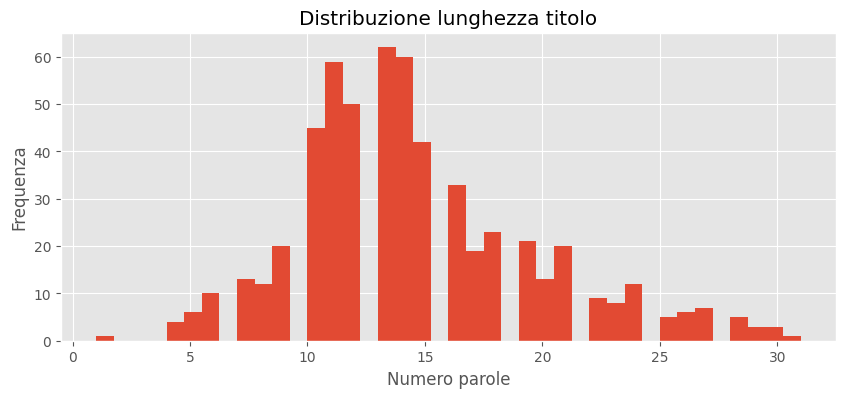

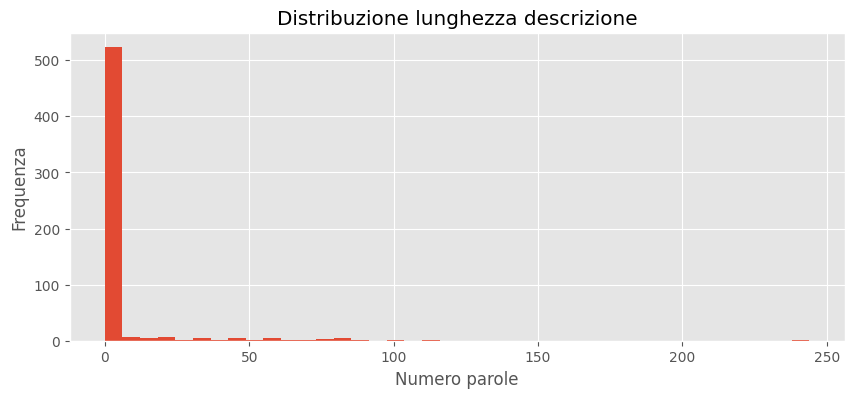


=== Numero features ===


C:\Users\ACER\AppData\Local\Temp\ipykernel_20376\645727124.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metadata_subset["num_features"] = metadata_subset["features"].apply(


count    572.000000
mean       1.784965
std        2.732868
min        0.000000
25%        0.000000
50%        0.000000
75%        2.000000
max       14.000000
Name: num_features, dtype: float64

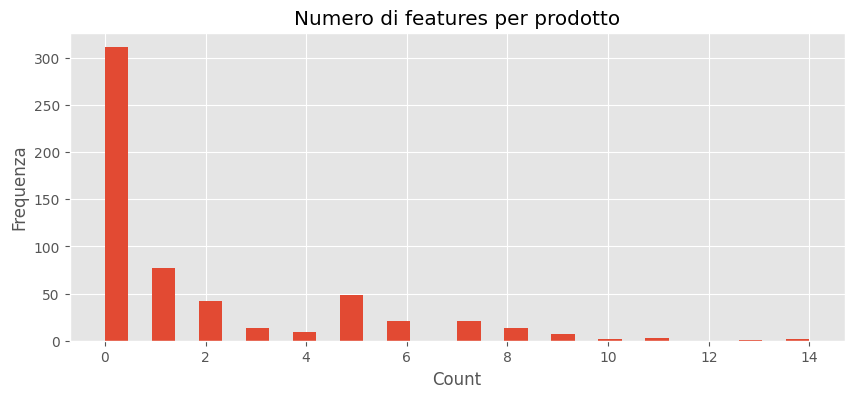


=== Prezzi ===


count    34.000000
mean     26.891471
std      24.423164
min       0.190000
25%      12.490000
50%      19.970000
75%      27.677500
max      99.990000
Name: price, dtype: float64

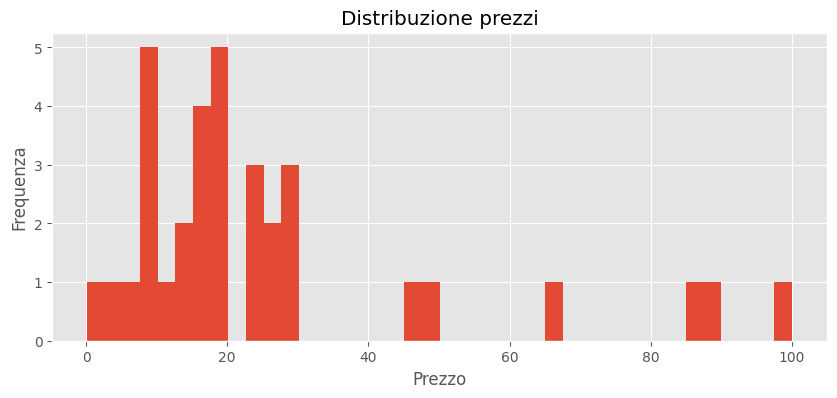


=== Numero immagini ===


C:\Users\ACER\AppData\Local\Temp\ipykernel_20376\645727124.py:111: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metadata_subset["num_images"] = metadata_subset["images"].apply(


count    572.000000
mean       4.893357
std        2.249146
min        1.000000
25%        3.000000
50%        6.000000
75%        7.000000
max        9.000000
Name: num_images, dtype: float64

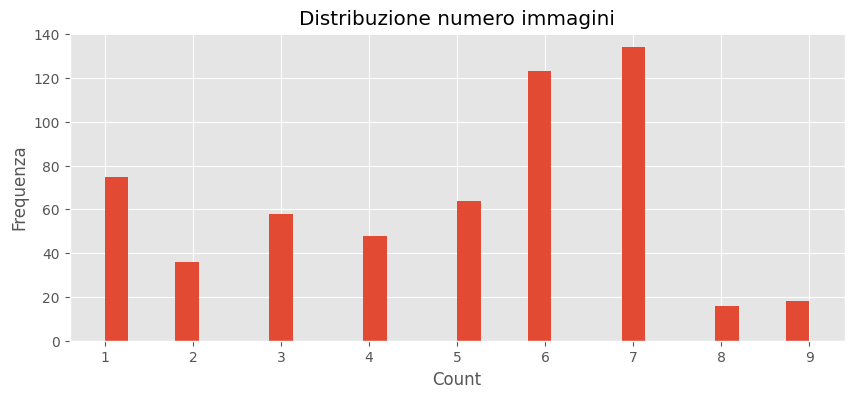

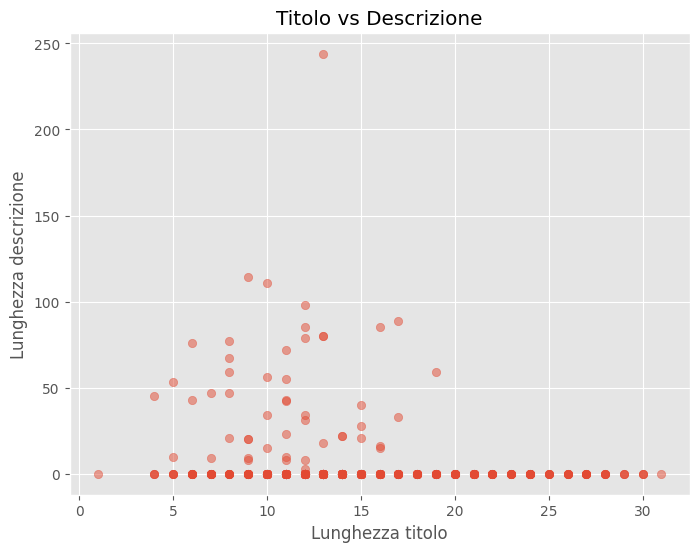

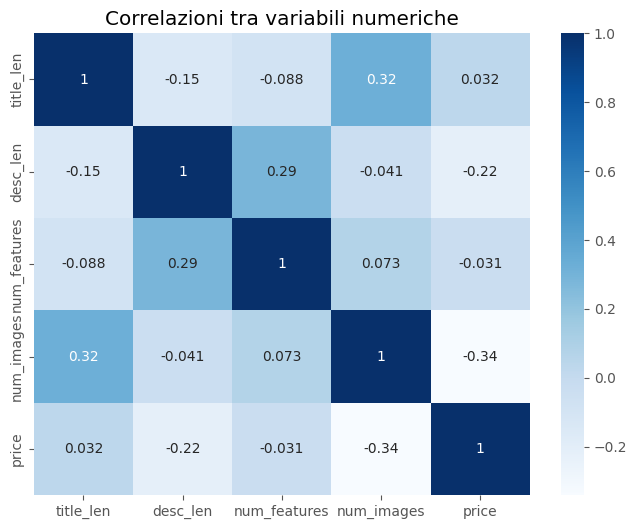


Top 10 categorie:


main_category
AMAZON FASHION    572
Name: count, dtype: int64


Top 10 store:


store
Orchid Row    32
SKYWAY        18
Ldurian       17
Panvbo        13
YAZILIND      12
Hugitout      11
QIYUN.Z       11
Skyway        10
Forcool        9
YEEPSYS        9
Name: count, dtype: int64


=== RIEPILOGO FINALE METADATA ===


,title_len_mean,desc_len_mean,num_features_mean,num_images_mean,price_mean
0,14.477273,4.167832,1.784965,4.893357,26.891471


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

# ------------------------------------------------------------
# 1. SETUP E DATI
# ------------------------------------------------------------

print("Shape metadata_subset:", metadata_subset.shape)

print("\nPrime righe:")
display(metadata_subset.head())

print("\nTipi di dato:")
display(metadata_subset.dtypes)


# ------------------------------------------------------------
# 2. QUALITÀ DEI DATI
# ------------------------------------------------------------

def summarize_metadata(df):
    summary = pd.DataFrame({
        "dtype": df.dtypes,
        "num_nulls": df.isnull().sum(),
        "pct_nulls": (df.isnull().mean() * 100).round(2)
    })
    return summary

print("\n=== Missing Values ===")
display(summarize_metadata(metadata_subset))


# ------------------------------------------------------------
# 3. ANALISI TITLE E DESCRIPTION
# ------------------------------------------------------------

metadata_subset["title_len"] = metadata_subset["title"].fillna("").apply(lambda x: len(str(x).split()))
metadata_subset["desc_len"] = metadata_subset["description"].fillna("").apply(
    lambda x: len((" ".join(x) if isinstance(x, list) else str(x)).split())
)

metadata_subset["desc_len"].describe()


print("\n=== Title Length ===")
display(metadata_subset["title_len"].describe())

print("\n=== Description Length ===")
display(metadata_subset["desc_len"].describe())

# Istogrammi
plt.figure(figsize=(10,4))
metadata_subset["title_len"].hist(bins=40)
plt.title("Distribuzione lunghezza titolo")
plt.xlabel("Numero parole")
plt.ylabel("Frequenza")
plt.show()

plt.figure(figsize=(10,4))
metadata_subset["desc_len"].hist(bins=40)
plt.title("Distribuzione lunghezza descrizione")
plt.xlabel("Numero parole")
plt.ylabel("Frequenza")
plt.show()


# ------------------------------------------------------------
# 4. FEATURES (se presenti)
# ------------------------------------------------------------

metadata_subset["num_features"] = metadata_subset["features"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

print("\n=== Numero features ===")
display(metadata_subset["num_features"].describe())

plt.figure(figsize=(10,4))
metadata_subset["num_features"].hist(bins=30)
plt.title("Numero di features per prodotto")
plt.xlabel("Count")
plt.ylabel("Frequenza")
plt.show()


# ------------------------------------------------------------
# 5. PREZZI
# ------------------------------------------------------------

valid_price = metadata_subset["price"].dropna()

print("\n=== Prezzi ===")
display(valid_price.describe())

plt.figure(figsize=(10,4))
plt.hist(valid_price, bins=40)
plt.title("Distribuzione prezzi")
plt.xlabel("Prezzo")
plt.ylabel("Frequenza")
plt.show()


# ------------------------------------------------------------
# 6. IMMAGINI
# ------------------------------------------------------------

metadata_subset["num_images"] = metadata_subset["images"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

print("\n=== Numero immagini ===")
display(metadata_subset["num_images"].describe())

plt.figure(figsize=(10,4))
metadata_subset["num_images"].hist(bins=30)
plt.title("Distribuzione numero immagini")
plt.xlabel("Count")
plt.ylabel("Frequenza")
plt.show()


# ------------------------------------------------------------
# 7. SCATTER TITLE vs DESCRIPTION
# ------------------------------------------------------------

plt.figure(figsize=(8,6))
plt.scatter(metadata_subset["title_len"], metadata_subset["desc_len"], alpha=0.5)
plt.xlabel("Lunghezza titolo")
plt.ylabel("Lunghezza descrizione")
plt.title("Titolo vs Descrizione")
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# 8. CORRELAZIONI NUMERICHE
# ------------------------------------------------------------

corr_cols = ["title_len", "desc_len", "num_features", "num_images", "price"]

numeric_df = metadata_subset[corr_cols].copy()
numeric_df = numeric_df.select_dtypes(include=[np.number])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="Blues")
plt.title("Correlazioni tra variabili numeriche")
plt.show()


# ------------------------------------------------------------
# 9. TOP categorie & store
# ------------------------------------------------------------

print("\nTop 10 categorie:")
display(metadata_subset["main_category"].value_counts().head(10))

print("\nTop 10 store:")
display(metadata_subset["store"].value_counts().head(10))


# ------------------------------------------------------------
# 10. RIEPILOGO FINALE
# ------------------------------------------------------------

summary = pd.DataFrame({
    "title_len_mean": [metadata_subset["title_len"].mean()],
    "desc_len_mean": [metadata_subset["desc_len"].mean()],
    "num_features_mean": [metadata_subset["num_features"].mean()],
    "num_images_mean": [metadata_subset["num_images"].mean()],
    "price_mean": [metadata_subset["price"].mean()]
})

print("\n=== RIEPILOGO FINALE METADATA ===")
display(summary)


## Configurazione Ottimale K-NN

> **Variabili rilevanti**
>  - **df_test** = DataFrame di test contentente il 20% delle recensioni di df_final
>  - **df_train** = DataFrame usato per il train del modello (circa 80% delle recensioni)
>  - **best_rmse** = Salva la configurazione ottimale di KNN
>  - **train_matrix** = Matrice CSR (Compressed Sparse Row) di utenti e item con valori i rating da 1 a 5
>


> **Librerie**
> - **scipy, scikit-learn, implicit, lightfm**


In [34]:
!pip install scipy
!pip install scikit-learn
!pip install implicit
!pip install lightfm


[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
#IMPORT
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.model_selection import train_test_split
from scipy.sparse import coo_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error



* *Pulizia NaN, Codifica Utenti e Item in Codici Numerici, Divisione Train e Test DataFrame (80/20)*

In [36]:
from scipy.sparse import coo_matrix
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# DATA CLEANING
df_final = df_final[['user_id', 'parent_asin', 'rating']].dropna().copy()

# TRAIN–TEST SPLIT
train_df, test_df = train_test_split(df_final, test_size=0.2, random_state=42)

# REINDEXING SOLO SUL TRAIN
train_df['user_idx'] = train_df['user_id'].astype('category').cat.codes
train_df['item_idx'] = train_df['parent_asin'].astype('category').cat.codes

# MAPPING ESPLICITO (fisso)
user_to_idx = {uid: idx for idx, uid in enumerate(train_df['user_id'].astype('category').cat.categories)}
item_to_idx = {iid: idx for idx, iid in enumerate(train_df['parent_asin'].astype('category').cat.categories)}

num_users = len(user_to_idx)
num_items = len(item_to_idx)

# MAPPING DEL TEST
test_df['user_idx'] = test_df['user_id'].apply(lambda x: user_to_idx.get(x, -1))
test_df['item_idx'] = test_df['parent_asin'].apply(lambda x: item_to_idx.get(x, -1))

# RIMOZIONE RIGHE NON PRESENTI NEL TRAIN
before = len(test_df)
test_df = test_df[(test_df.user_idx != -1) & (test_df.item_idx != -1)]
after = len(test_df)

print("Rimosse", before - after, "righe dal test.")
print("max user_idx test:", test_df.user_idx.max(), "/", num_users-1)
print("max item_idx test:", test_df.item_idx.max(), "/", num_items-1)

# MATRICE USER × ITEM
train_matrix = coo_matrix(
    (train_df['rating'], (train_df['user_idx'], train_df['item_idx'])),
    shape=(num_users, num_items)
).tocsr()


Rimosse 12 righe dal test.
max user_idx test: 962 / 962
max item_idx test: 571 / 571


In [37]:
def compute_baselines(R, lambda_user=10, lambda_item=25, n_iter=10):
    """
    Calcolo μ, b_u, b_i con ALS identico a Surprise.KNNBaseline.
    R: matrice user × item con 0 = missing
    """
    mask = (R > 0)
    mu = R[mask].mean()

    num_users, num_items = R.shape
    bu = np.zeros(num_users)
    bi = np.zeros(num_items)

    for _ in range(n_iter):
        # update user biases
        for u in range(num_users):
            idx = mask[u]
            if idx.any():
                bu[u] = (R[u, idx] - mu - bi[idx]).sum() / (lambda_user + idx.sum())

        # update item biases
        for i in range(num_items):
            idx = mask[:, i]
            if idx.any():
                bi[i] = (R[idx, i] - mu - bu[idx]).sum() / (lambda_item + idx.sum())

    return mu, bu, bi

def compute_similarity(R, mu, bu, bi, shrinkage=100, similarity="cosine", user_based=False):
    """
    Similarità in stile Surprise (cosine, adjusted cosine, pearson).
    Restituisce SEMPRE:
        - item×item matrix se user_based=False
        - user×user matrix se user_based=True

    Parametri:
        R : matrice ratings (numpy array)
        mu, bu, bi: baseline components
        shrinkage: shrink Surprise-like
        similarity: "cosine", "adjusted", "pearson"
        user_based: False=item-based, True=user-based
    """

    # --------------------------------
    # 1) Prepara deviazioni dal baseline
    # --------------------------------
    mask = (R > 0)
    baseline = mu + bu[:, None] + bi[None, :]
    dev = (R - baseline) * mask

    # --------------------------------
    # 2) Seleziona asse corretto
    # --------------------------------
    if not user_based:
        # ITEM-BASED
        # A = item × users
        A = dev.T
        A_mask = mask.T
    else:
        # USER-BASED
        # A = user × items
        A = dev
        A_mask = mask

    # A shape: (num_entities, num_features)
    n = A.shape[0]   # items or users

    # --------------------------------
    # 3) Similarità
    # --------------------------------
    if similarity == "cosine":
        norms = np.sqrt((A ** 2).sum(axis=1)) + 1e-8
        sim = (A @ A.T) / (norms[:, None] * norms[None, :])

    elif similarity == "adjusted":
        means = np.divide(A.sum(axis=1), A_mask.sum(axis=1) + 1e-8)[:, None]
        A_adj = (A - means) * A_mask

        norms = np.sqrt((A_adj ** 2).sum(axis=1)) + 1e-8
        sim = (A_adj @ A_adj.T) / (norms[:, None] * norms[None, :])

    elif similarity == "pearson":
        means = np.divide(A.sum(axis=1), A_mask.sum(axis=1) + 1e-8)[:, None]
        A_centered = (A - means) * A_mask

        norms = np.sqrt((A_centered ** 2).sum(axis=1)) + 1e-8
        sim = (A_centered @ A_centered.T) / (norms[:, None] * norms[None, :])

    else:
        raise ValueError("Unknown similarity type")

    # --------------------------------
    # 4) Shrinkage Surprise-like
    # --------------------------------
    counts = A_mask @ A_mask.T
    sim = sim * (counts / (counts + shrinkage))

    # --------------------------------
    # 5) No auto-similiarità
    # --------------------------------
    np.fill_diagonal(sim, 0)

    return sim

    """
    Similarità stile Surprise (cosine / adjusted cosine / pearson).
    Computata su deviazioni dai baseline.
    """

    mask = (R > 0)
    baseline = mu + bu[:, None] + bi[None, :]
    dev = (R - baseline) * mask

    # Trasforma matrix se user_based
    M = dev if not user_based else dev.T
    Mmask = mask if not user_based else mask.T

    # Numero di entità (items se item-based, users se user-based)
    n = M.shape[0]

    if similarity == "cosine":
        norms = np.sqrt((M ** 2).sum(axis=1)) + 1e-8
        sim = (M @ M.T) / (norms[:, None] * norms[None, :])

    elif similarity == "adjusted":
        # media per riga
        means = np.divide(
            M.sum(axis=1),
            (Mmask.sum(axis=1) + 1e-8)
        )[:, None]
        Adj = (M - means) * Mmask

        norms = np.sqrt((Adj ** 2).sum(axis=1)) + 1e-8
        sim = (Adj @ Adj.T) / (norms[:, None] * norms[None, :])

    elif similarity == "pearson":
        means = np.divide(
            M.sum(axis=1),
            (Mmask.sum(axis=1) + 1e-8)
        )[:, None]
        centered = (M - means) * Mmask

        norms = np.sqrt((centered ** 2).sum(axis=1)) + 1e-8
        sim = (centered @ centered.T) / (norms[:, None] * norms[None, :])

    else:
        raise ValueError("Invalid similarity type")

    # shrinkage Surprise-style
    counts = Mmask @ Mmask.T  # co-rating matrix
    sim *= counts / (counts + shrinkage)

    np.fill_diagonal(sim, 0)

    return sim

def predict_knn_baseline(u, i, R, sim, mu, bu, bi, k=40, user_based=False):
    """
    r̂_ui = b_ui + sum(w * dev) / sum(|w|)
    Identico a Surprise.KNNBaseline
    """
    baseline = mu + bu[u] + bi[i]

    if not user_based:
        sims = sim[i]     # item → item
        ratings = R[u]    # ratings dell'utente
    else:
        sims = sim[u]     # user → user
        ratings = R[:, i] # ratings dell'item

    # ordina i vicini
    neigh_idx = np.argsort(sims)[::-1]

    num = 0
    den = 0
    count = 0

    for j in neigh_idx:
        if not user_based:
            ruj = ratings[j]
            if ruj == 0:
                continue
            dev = ruj - (mu + bu[u] + bi[j])
            w = sims[j]
        else:
            rji = ratings[j]
            if rji == 0:
                continue
            dev = rji - (mu + bu[j] + bi[i])
            w = sims[j]

        num += w * dev
        den += abs(w)
        count += 1

        if count == k:
            break

    if den == 0:
        return baseline

    pred = baseline + num / den
    return min(5, max(1, pred))

def evaluate_knn_baseline(test_df, R, sim, mu, bu, bi, k=40, user_based=False):
    trues, preds = [], []

    for _, row in test_df.iterrows():
        u = row.user_idx
        i = row.item_idx
        if u < 0 or i < 0:
            continue

        trues.append(row.rating)
        preds.append(
            predict_knn_baseline(u, i, R, sim, mu, bu, bi, k=k, user_based=user_based)
        )

    mse = mean_squared_error(trues, preds)
    return mse, np.sqrt(mse), mean_absolute_error(trues, preds)

def fill_matrix_knn_baseline(R, sim, mu, bu, bi, k=40, user_based=False):
    filled = R.copy().astype(float)
    num_users, num_items = R.shape

    for u in range(num_users):
        for i in range(num_items):
            if filled[u, i] == 0:
                filled[u, i] = predict_knn_baseline(
                    u, i, R, sim, mu, bu, bi, k=k, user_based=user_based
                )
    return filled

def grid_search_knn_baseline(
    train_R,
    test_df,
    k_values=[20, 40, 80],
    similarities=["cosine", "adjusted", "pearson"],
    shrinkages=[10, 50, 100],
    user_based_values=[False, True],
    lambda_user=10,
    lambda_item=25,
):
    """
    Grid Search in stile Surprise per KNNBaseline.

    Restituisce:
      - best_config   (dict dei parametri migliori)
      - best_metrics  (mse, rmse, mae)
      - best_sim      (matrice di similarità migliore)
      - best_baseline (mu, bu, bi)

    train_R = matrice user×item CSR o array numpy
    test_df = DataFrame con user_idx, item_idx, rating
    """

    # Convert sparse → dense (solo se train_R è sparse)
    R = train_R.toarray() if hasattr(train_R, "toarray") else train_R.copy()

    # -------------------------------
    # COMPUTE BASELINES (1 sola volta)
    # -------------------------------
    print("→ Calcolo baselines (μ, b_u, b_i)...")
    mu, bu, bi = compute_baselines(
        R,
        lambda_user=lambda_user,
        lambda_item=lambda_item
    )

    best_rmse = 1e9
    best_config = None
    best_metrics = None
    best_sim = None

    # -------------------------------
    # GRID SEARCH
    # -------------------------------
    for sim_name in similarities:
        print(f"\n### SIMILARITÀ = {sim_name}")

        for shrink in shrinkages:
            print(f"  - shrink = {shrink}")

            for user_based in user_based_values:
                mode = "USER-USER" if user_based else "ITEM-ITEM"
                print(f"    - user_based = {mode}")

                # COMPUTE SIMILARITY
                sim = compute_similarity(
                    R, mu, bu, bi,
                    shrinkage=shrink,
                    similarity=sim_name,
                    user_based=user_based
                )

                for k in k_values:
                    print(f"       → testing k={k}... ", end="")

                    mse, rmse, mae = evaluate_knn_baseline(
                        test_df,
                        R,
                        sim,
                        mu, bu, bi,
                        k=k,
                        user_based=user_based
                    )

                    print(f"RMSE={rmse:.4f}")

                    # update best
                    if rmse < best_rmse:
                        best_rmse = rmse
                        best_config = {
                            "similarity": sim_name,
                            "shrinkage": shrink,
                            "user_based": user_based,
                            "k": k,
                            "lambda_user": lambda_user,
                            "lambda_item": lambda_item
                        }
                        best_sim = sim
                        best_metrics = {
                            "mse": mse,
                            "rmse": rmse,
                            "mae": mae
                        }

    print("\n==============================")
    print("   BEST CONFIGURATION FOUND   ")
    print("==============================")
    print(best_config)
    print(best_metrics)

    return best_config, best_metrics, best_sim, (mu, bu, bi)

def verify_filling(R, R_filled):
    """
    Controlla che il filling sia stato eseguito correttamente.
    """
    print("\n===== VERIFICA FILLING =====")

    # 1. Shape coerente
    print("Shape originale:", R.shape)
    print("Shape filled    :", R_filled.shape)
    assert R.shape == R_filled.shape, "❌ Shape diversa!"

    # 2. Nessuno zero nella matrice filled
    num_zeros = np.sum(R_filled == 0)
    print("Zeri trovati nella matrice filled:", num_zeros)
    assert num_zeros == 0, "❌ Sono rimasti degli zeri!"

    # 3. Valori nel range [1,5]
    out_of_range = np.sum((R_filled < 1) | (R_filled > 5))
    print("Valori fuori range [1,5]:", out_of_range)
    assert out_of_range == 0, "❌ Valori fuori dal range consentito!"

    # 4. I rating originali devono rimanere identici
    mask_observed = (R > 0)
    mismatches = np.sum(R[mask_observed] != R_filled[mask_observed])
    print("Valori originali modificati:", mismatches)
    assert mismatches == 0, "❌ Alcuni rating originali sono cambiati!"

    # 5. Quanti valori sono stati riempiti
    num_missing_before = np.sum(R == 0)
    print("Valori riempiti:", num_missing_before)

    print("\n✅ Tutti i controlli superati. Il filling è corretto.")

In [38]:
R = train_matrix.toarray()

best_config, best_metrics, best_sim, (mu, bu, bi) = grid_search_knn_baseline(
    train_R=train_matrix,  # oppure R
    test_df=test_df,
    k_values = [5, 10, 20, 30, 40, 60, 80, 100],
    similarities=["cosine", "adjusted", "pearson"],
    shrinkages=[10, 50, 100],
    user_based_values=[False, True],   # provi item-item e user-user
    lambda_user=10,
    lambda_item=25
)

print("MIGLIOR CONFIGURAZIONE:")
print(best_config)

print("MIGLIORI METRICHE:")
print(best_metrics)

→ Calcolo baselines (μ, b_u, b_i)...

### SIMILARITÀ = cosine
  - shrink = 10
    - user_based = ITEM-ITEM
       → testing k=5... RMSE=1.1026
       → testing k=10... RMSE=1.1084
       → testing k=20... RMSE=1.1029
       → testing k=30... RMSE=1.0985
       → testing k=40... RMSE=1.0989
       → testing k=60... RMSE=1.0979
       → testing k=80... RMSE=1.0979
       → testing k=100... RMSE=1.0979
    - user_based = USER-USER
       → testing k=5... RMSE=1.0677
       → testing k=10... RMSE=1.0626
       → testing k=20... RMSE=1.0645
       → testing k=30... RMSE=1.0684
       → testing k=40... RMSE=1.0713
       → testing k=60... RMSE=1.0693
       → testing k=80... RMSE=1.0693
       → testing k=100... RMSE=1.0693
  - shrink = 50
    - user_based = ITEM-ITEM
       → testing k=5... RMSE=1.1026
       → testing k=10... RMSE=1.1084
       → testing k=20... RMSE=1.1029
       → testing k=30... RMSE=1.0985
       → testing k=40... RMSE=1.0989
       → testing k=60... RMSE=1.0979
      

➤ Best K = 10
➤ User-based = True
➤ Similarity = cosine
➤ Shrinkage = 50


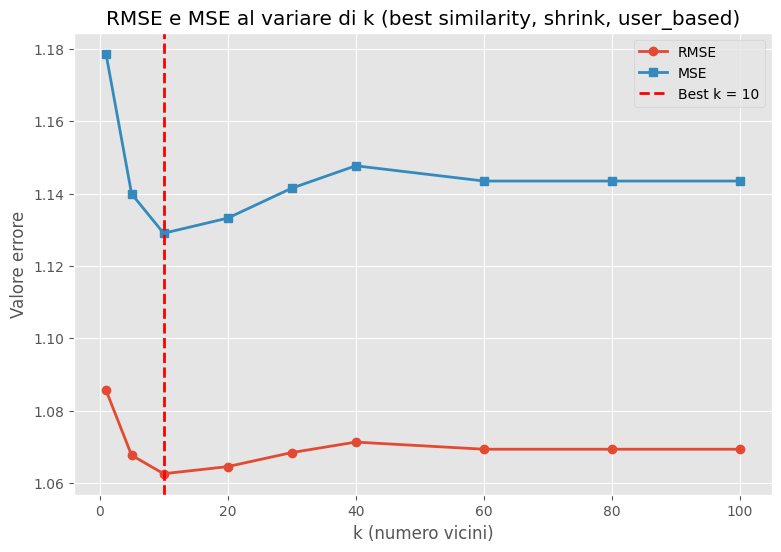

In [39]:
import numpy as np
import matplotlib.pyplot as plt

def plot_rmse_mse_vs_k(
    R, test_df, best_sim, mu, bu, bi,
    user_based, k_values, best_k
):
    rmses = []
    mses = []

    for k in k_values:
        mse, rmse, mae = evaluate_knn_baseline(
            test_df=test_df,
            R=R,
            sim=best_sim,
            mu=mu,
            bu=bu,
            bi=bi,
            k=k,
            user_based=user_based
        )
        rmses.append(rmse)
        mses.append(mse)

    plt.figure(figsize=(9, 6))

    # Curves
    plt.plot(k_values, rmses, marker='o', label="RMSE", linewidth=2)
    plt.plot(k_values, mses, marker='s', label="MSE", linewidth=2)

    # Best k line
    plt.axvline(best_k, color='red', linestyle='--', linewidth=2,
                label=f"Best k = {best_k}")

    plt.xlabel("k (numero vicini)")
    plt.ylabel("Valore errore")
    plt.title("RMSE e MSE al variare di k (best similarity, shrink, user_based)")
    plt.legend()
    plt.grid(True)
    plt.show()

# Estraggo i parametri dalla best config
best_k = best_config["k"]
best_user_based = best_config["user_based"]
best_similarity = best_config["similarity"]
best_shrink = best_config["shrinkage"]

print("➤ Best K =", best_k)
print("➤ User-based =", best_user_based)
print("➤ Similarity =", best_similarity)
print("➤ Shrinkage =", best_shrink)

# Lista valori K da testare nel plot
k_values = [1, 5, 10, 20, 30, 40, 60, 80, 100]

plot_rmse_mse_vs_k(
    R=R,
    test_df=test_df,
    best_sim=best_sim,
    mu=mu,
    bu=bu,
    bi=bi,
    user_based=best_user_based,
    best_k=best_k,
    k_values=k_values
)



## Filling Matrice - Best Config

> **Variabili rilevanti**
>  - **df_test** = DataFrame di test contentente il 20% delle recensioni di df_final
>  - **df_train** = DataFrame usato per il train del modello (circa 80% delle recensioni)
>  - **best_rmse** = Salva la configurazione ottimale di KNN
>  - **train_matrix** = Matrice CSR (Compressed Sparse Row) di utenti e item con valori i rating da 1 a 5
>


> **Librerie**
> - **scipy, scikit-learn, implicit, lightfm**


In [40]:
#Import
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np


In [41]:
# 1. FILLING CON LA BEST CONFIG
best_k = best_config["k"]
best_user_based = best_config["user_based"]

R_filled = fill_matrix_knn_baseline(
    R=R,
    sim=best_sim,
    mu=mu,
    bu=bu,
    bi=bi,
    k=best_k,
    user_based=best_user_based
)

# 2. VERIFICA COMPLETA
verify_filling(R, R_filled)



===== VERIFICA FILLING =====
Shape originale: (963, 572)
Shape filled    : (963, 572)
Zeri trovati nella matrice filled: 0
Valori fuori range [1,5]: 0
Valori originali modificati: 0
Valori riempiti: 546957

✅ Tutti i controlli superati. Il filling è corretto.


## Segmentazione Utenti

In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

# Standardizzazione (molto importante!)
scaler = StandardScaler()
R_scaled = scaler.fit_transform(R_filled)

# PCA
pca = PCA(n_components=20, random_state=42)
R_pca = pca.fit_transform(R_scaled)

print("Shape PCA:", R_pca.shape)  # (963, 50)


Shape PCA: (963, 20)


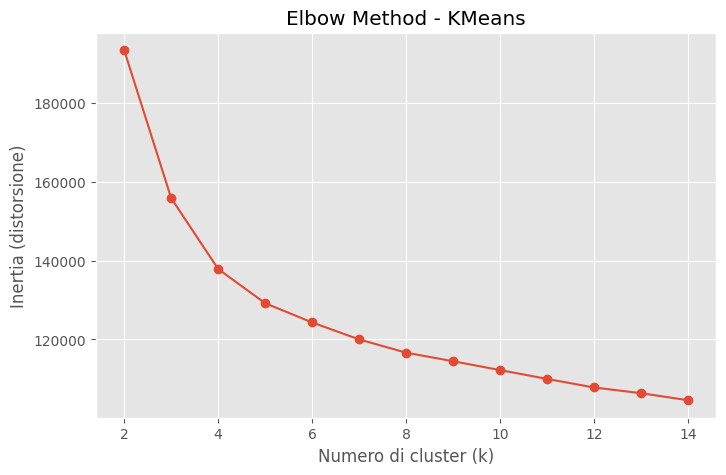

In [43]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
K_range = range(2, 15)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=50)
    km.fit(R_pca)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertias, marker='o')
plt.title("Elbow Method - KMeans")
plt.xlabel("Numero di cluster (k)")
plt.ylabel("Inertia (distorsione)")
plt.grid(True)
plt.show()


k=2 → silhouette=0.3948
k=3 → silhouette=0.2954
k=4 → silhouette=0.2097
k=5 → silhouette=0.1600
k=6 → silhouette=0.1606
k=7 → silhouette=0.1271
k=8 → silhouette=0.1098
k=9 → silhouette=0.1114
k=10 → silhouette=0.1035
k=11 → silhouette=0.1102
k=12 → silhouette=0.0990
k=13 → silhouette=0.0814
k=14 → silhouette=0.0924


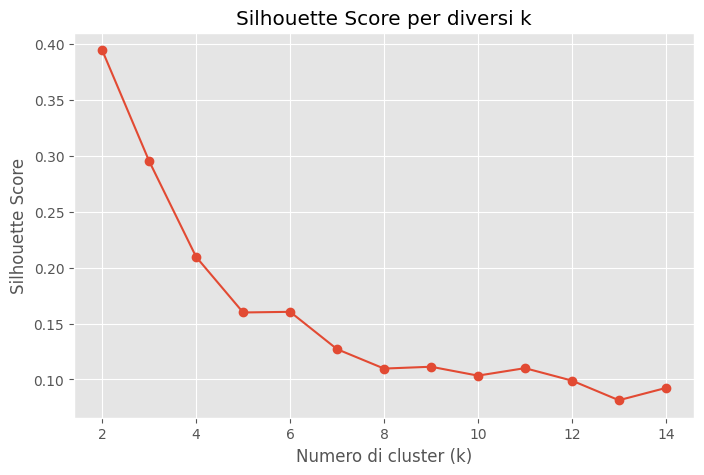

In [44]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = km.fit_predict(R_pca)
    sil = silhouette_score(R_pca, labels)
    sil_scores.append(sil)
    print(f"k={k} → silhouette={sil:.4f}")

# Plot silhouette
plt.figure(figsize=(8,5))
plt.plot(K_range, sil_scores, marker='o')
plt.title("Silhouette Score per diversi k")
plt.xlabel("Numero di cluster (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()


In [45]:
best_k = 6

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=50)
user_clusters = kmeans.fit_predict(R_pca)

print("Numero utenti in ciascun cluster:")
print(np.bincount(user_clusters))
from sklearn.metrics import silhouette_score
print("Silhouette finale ottimizzato:", silhouette_score(R_pca, user_clusters))



Numero utenti in ciascun cluster:
[141 291  63 198 228  42]
Silhouette finale ottimizzato: 0.16057593237481585


Shape PCA 2D: (963, 2)


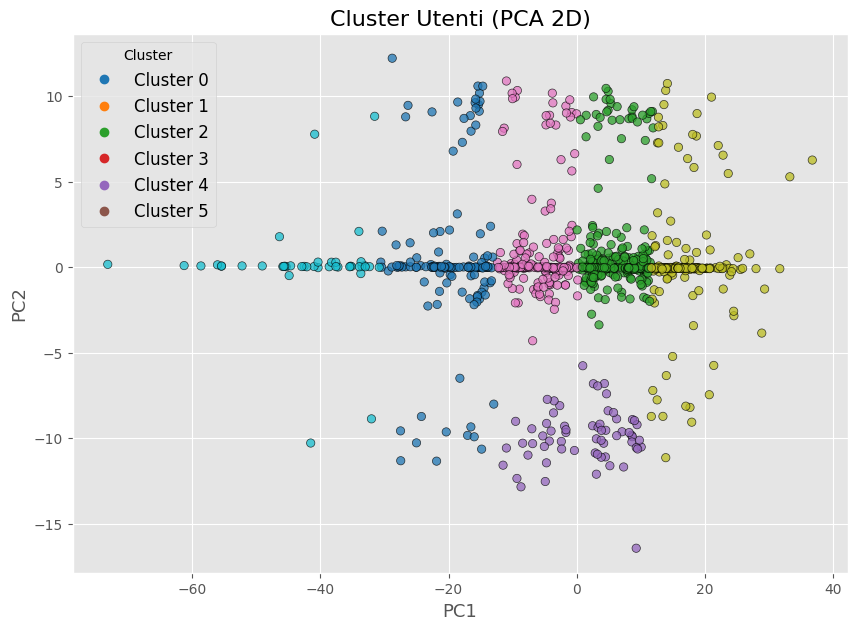

(963, 20)

Silhouette Score finale (k=6): 0.1606


In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# -----------------------------
# 1. STANDARDIZZAZIONE + PCA 2D
# -----------------------------

scaler = StandardScaler()
R_scaled = scaler.fit_transform(R_filled)

pca2d = PCA(n_components=2, random_state=42)
R_pca_2d = pca2d.fit_transform(R_scaled)

print("Shape PCA 2D:", R_pca_2d.shape)


# -----------------------------
# 2. GRAFICO DEI CLUSTER IN 2D
# -----------------------------

plt.figure(figsize=(10, 7))
plt.scatter(
    R_pca_2d[:, 0],
    R_pca_2d[:, 1],
    c=user_clusters,
    cmap="tab10",
    alpha=0.75,
    edgecolor='k'
)

plt.title("Cluster Utenti (PCA 2D)", fontsize=16)
plt.xlabel("PC1", fontsize=13)
plt.ylabel("PC2", fontsize=13)
plt.grid(True)

# Legenda dei cluster
unique_clusters = np.unique(user_clusters)
handles = [
    plt.Line2D([], [], marker='o', linestyle='', color=plt.cm.tab10(c), 
               label=f"Cluster {c}")
    for c in unique_clusters
]
plt.legend(handles=handles, title="Cluster", fontsize=12)

plt.show()


# -----------------------------
# 3. SILHOUETTE SCORE FINALE
# -----------------------------

sil = silhouette_score(R_pca, user_clusters)
print(R_pca.shape)
print(f"\nSilhouette Score finale (k={len(unique_clusters)}): {sil:.4f}")


In [47]:
import numpy as np
import pandas as pd

# ===================================
# ANALISI DEI 6 CLUSTER
# ===================================

num_clusters = len(np.unique(user_clusters))

print("\n==============================")
print(" ANALISI DEI CLUSTER UTENTI")
print("==============================\n")

cluster_analysis = []

for c in range(num_clusters):

    # utenti nel cluster
    users_in_cluster = np.where(user_clusters == c)[0]

    # estrai le righe del dataframe originale
    df_cluster = train_df[train_df.user_idx.isin(users_in_cluster)]

    # numero utenti
    n_users = len(users_in_cluster)

    # rating medi cluster
    mean_rating = df_cluster.rating.mean()
    std_rating = df_cluster.rating.std()

    # numero medio recensioni per utente
    ratings_per_user = df_cluster.groupby("user_idx").size().mean()

    # top item più apprezzati
    top_items = (
        df_cluster.groupby("parent_asin")["rating"]
        .mean()
        .sort_values(ascending=False)
        .head(10)
    )

    cluster_analysis.append({
        "cluster": c,
        "n_users": n_users,
        "mean_rating": mean_rating,
        "std_rating": std_rating,
        "ratings_per_user": ratings_per_user,
        "top_items": top_items
    })


# ===================================
# STAMPA RISULTATI
# ===================================

for info in cluster_analysis:
    print(f"\n---------------------------------------")
    print(f" CLUSTER {info['cluster']}")
    print(f"---------------------------------------")
    print(f"Numero utenti:             {info['n_users']}")
    print(f"Rating medio:              {info['mean_rating']:.3f}")
    print(f"Deviazione standard:       {info['std_rating']:.3f}")
    print(f"Recensioni medie per user: {info['ratings_per_user']:.2f}")

    print("\nTop 10 item più apprezzati:")
    print(info['top_items'])

    # Profilo qualitativo automatico
    print("\nProfilo cluster:")
    if info["mean_rating"] > 4.2:
        print(" - Utenti molto positivi, tendono a dare voti alti.")
    elif info["mean_rating"] > 3.8:
        print(" - Utenti generalmente positivi, valutano sopra la media.")
    elif info["mean_rating"] > 3.2:
        print(" - Utenti equilibrati, mix di voti vari.")
    elif info["mean_rating"] > 2.5:
        print(" - Utenti critici, tendono a dare valutazioni più basse.")
    else:
        print(" - Utenti molto critici, valutazioni spesso negative.")

    if info["ratings_per_user"] > 10:
        print(" - Many-rater: utenti che lasciano molte recensioni.")
    elif info["ratings_per_user"] > 5:
        print(" - Utenti medi, buona attività.")
    else:
        print(" - Light-rater: pochi rating per utente.")

    print("---------------------------------------")



 ANALISI DEI CLUSTER UTENTI


---------------------------------------
 CLUSTER 0
---------------------------------------
Numero utenti:             141
Rating medio:              3.354
Deviazione standard:       1.205
Recensioni medie per user: 4.37

Top 10 item più apprezzati:
parent_asin
B07ZX1XLZR    5.0
B07SGC9NSV    5.0
B07WY5GBTB    5.0
B00QKAH1P6    5.0
B00PJIQPNO    5.0
B00PJIPZGW    5.0
B00OCAA3T2    5.0
B00OCA9ZGY    5.0
B07SGCNG7N    5.0
B08K2L2VPZ    5.0
Name: rating, dtype: float64

Profilo cluster:
 - Utenti equilibrati, mix di voti vari.
 - Light-rater: pochi rating per utente.
---------------------------------------

---------------------------------------
 CLUSTER 1
---------------------------------------
Numero utenti:             291
Rating medio:              4.513
Deviazione standard:       0.701
Recensioni medie per user: 3.37

Top 10 item più apprezzati:
parent_asin
B007CS43EW    5.0
B07NNY7PCK    5.0
B07PJ2DJRD    5.0
B07PM2F9CT    5.0
B07PW3YVZ7    5.0
B07PX95

## Lista Top N Items

In [48]:
import numpy as np

def get_top_n_for_user(user_idx=None, N=10, R_filled=None, train_df=None, idx_to_item=None):
    """
    Ritorna i Top-N item raccomandati per un utente.

    - user_idx: indice utente (se None → random)
    - N: top N item da ritornare
    - R_filled: matrice filled (users × items)
    - train_df: dataframe con colonne user_idx, item_idx
    - idx_to_item: mapping index->ASIN
    """

    num_users, num_items = R_filled.shape

    # Se non passo un utente → pesco random
    if user_idx is None:
        user_idx = np.random.randint(0, num_users)
        print(f"[INFO] Utente scelto random: {user_idx}")

    # Set di item già recensiti dall'utente
    rated_items = set(train_df[train_df.user_idx == user_idx]["item_idx"])

    # Prendi tutti i rating predetti per l'utente
    user_ratings = R_filled[user_idx, :]

    # Filtra item già visti
    mask_not_seen = [i for i in range(num_items) if i not in rated_items]

    # Ordina i rimanenti in base al rating predetto (decrescente)
    top_indices = sorted(mask_not_seen, key=lambda i: user_ratings[i], reverse=True)[:N]

    # Converti idx → ASIN se mapping disponibile
    if idx_to_item is not None:
        recommended_items = [(idx_to_item[i], user_ratings[i]) for i in top_indices]
    else:
        recommended_items = [(i, user_ratings[i]) for i in top_indices]

    return user_idx, recommended_items


In [49]:
idx_to_item = {v: k for k, v in item_to_idx.items()}

user_idx, top_items = get_top_n_for_user(
    user_idx=None,    # random
    N=10,
    R_filled=R_filled,
    train_df=train_df,
    idx_to_item=idx_to_item
)

print("Utente:", user_idx)
for asin, score in top_items:
    print(f"{asin}: {score:.3f}")


[INFO] Utente scelto random: 900
Utente: 900
B07MSPZ4H6: 5.000
B07RV4GGTG: 5.000
B07SJ47VH6: 5.000
B07VDCS9FW: 5.000
B07W7B5SRQ: 5.000
B07XCMV62N: 5.000
B07YSP6S8D: 5.000
B07ZK52MM3: 5.000
B07ZKWX7C8: 5.000
B083CW5WRX: 5.000


In [50]:
print("\n==============================")
print("  TOP-10 RACCOMANDATI PER CLUSTER")
print("==============================\n")

users_by_cluster = {}

# Seleziona 1 utente per cluster
for cluster_id in np.unique(user_clusters):
    # trova utenti nel cluster
    users_in_cluster = np.where(user_clusters == cluster_id)[0]
    
    # prendi il PRIMO utente del cluster
    user_sample = users_in_cluster[0]
    users_by_cluster[cluster_id] = user_sample

    print(f"CLUSTER {cluster_id} → Utente scelto: {user_sample}")
    
    # ottieni le top-10
    uid, recommendations = get_top_n_for_user(
        user_idx=user_sample,
        N=10,
        R_filled=R_filled,
        train_df=train_df,
        idx_to_item=idx_to_item
    )

    # stampa top 10
    print("Top 10 raccomandazioni:")
    for asin, score in recommendations:
        print(f"  {asin}: {score:.3f}")

    print("----------------------------------------\n")



  TOP-10 RACCOMANDATI PER CLUSTER

CLUSTER 0 → Utente scelto: 17
Top 10 raccomandazioni:
  B00MVRDOZ8: 5.000
  B00SH9BD0W: 5.000
  B00ZIK4NH8: 5.000
  B00KA3R3M0: 4.921
  B00Y8563X6: 4.921
  B00N9X8VHY: 4.824
  B00XN7W85W: 4.824
  B00D08IGK0: 4.794
  B00V829KIW: 4.789
  B018DXKB8G: 4.784
----------------------------------------

CLUSTER 1 → Utente scelto: 1
Top 10 raccomandazioni:
  B00FNPPQS8: 5.000
  B00JN2W0LI: 5.000
  B00N9X64RI: 5.000
  B00UN2Z230: 5.000
  B00VHR5ST8: 5.000
  B08WPY8855: 5.000
  B00VECGKYS: 4.999
  B00HH975RS: 4.977
  B00KIFXWJS: 4.958
  B015DU8BOS: 4.918
----------------------------------------

CLUSTER 2 → Utente scelto: 6
Top 10 raccomandazioni:
  B07D4Q3WC6: 5.000
  B07GPT7DFV: 5.000
  B07PXB1N6F: 5.000
  B07SFM565Z: 5.000
  B07SGCNG7N: 5.000
  B07T3YGVF6: 5.000
  B07W77WY5H: 5.000
  B07WLK4FTS: 5.000
  B07S6N1VR4: 4.974
  B07ZWZD1ML: 4.912
----------------------------------------

CLUSTER 3 → Utente scelto: 10
Top 10 raccomandazioni:
  B07MSPZ4H6: 5.000
  B0

## Matrix Factorization con SVD

In [51]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.sparse.linalg import svds

def compute_svd_mf(R, k=50):
    """
    Matrix Factorization tramite Truncated SVD.
    """
    # SVD
    U, s, Vt = svds(R, k=k)

    # ordina i valori singolari (svds li dà in ordine crescente)
    s = s[::-1]
    U = U[:, ::-1]
    Vt = Vt[::-1, :]

    # ricostruzione matrice predetta
    R_hat = np.dot(np.dot(U, np.diag(s)), Vt)

    return R_hat, U, s, Vt

def evaluate_svd(test_df, R_hat):
    preds = []
    trues = []

    for _, row in test_df.iterrows():
        u = int(row.user_idx)
        i = int(row.item_idx)

        trues.append(row.rating)
        preds.append(R_hat[u, i])

    mse = mean_squared_error(trues, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(trues, preds)
    return mse, rmse, mae



def get_top_n_svd(user_idx, N=10, R_hat=None, train_df=None, idx_to_item=None):
    # item già recensiti
    rated_items = set(train_df[train_df.user_idx == user_idx]['item_idx'])

    user_ratings = R_hat[user_idx, :]

    mask_not_seen = [i for i in range(len(user_ratings)) if i not in rated_items]

    top_items = sorted(mask_not_seen, key=lambda i: user_ratings[i], reverse=True)[:N]

    if idx_to_item:
        return [(idx_to_item[i], user_ratings[i]) for i in top_items]
    return [(i, user_ratings[i]) for i in top_items]


In [52]:
R_mf = R_filled.copy().astype(float)
num_users, num_items = R_mf.shape

R_hat_svd, U_svd, s_svd, Vt_svd = compute_svd_mf(R_filled, k=50)


mse_svd, rmse_svd, mae_svd = evaluate_svd(test_df, R_hat_svd)


print("=== MF (SVD) PERFORMANCE ===")
print("RMSE:", rmse_svd)
print("MAE :", mae_svd)
print("RMSE:", mse_svd)


=== MF (SVD) PERFORMANCE ===
RMSE: 1.0254446661595644
MAE : 0.7689534332472722
RMSE: 1.0515367633551007


In [53]:
user = np.random.randint(0, num_users)
print("Utente scelto:", user)

print("\n--- TOP-N KNN Baseline ---")
_, top_knn = get_top_n_for_user(
    user_idx=user,
    N=10,
    R_filled=R_filled,
    train_df=train_df,
    idx_to_item=idx_to_item
)
for asin, score in top_knn:
    print(f"{asin}: {score:.3f}")

print("\n--- TOP-N MF (SVD) ---")
top_svd = get_top_n_svd(
    user_idx=user,
    N=10,
    R_hat=R_hat_svd,
    train_df=train_df,
    idx_to_item=idx_to_item
)
for asin, score in top_svd:
    print(f"{asin}: {score:.3f}")


Utente scelto: 156

--- TOP-N KNN Baseline ---
B007CS43EW: 5.000
B00HH975RS: 5.000
B00KA3QT8Y: 5.000
B00KA3SRVG: 5.000
B00KA3TUNA: 5.000
B00KA3VMTU: 5.000
B00KA3VX62: 5.000
B00KT13502: 5.000
B00KW02QK0: 5.000
B00KW4L9XQ: 5.000

--- TOP-N MF (SVD) ---
B00LMU9NE6: 5.250
B00Y8563X6: 5.201
B00VBA6ZAC: 5.161
B00LMUA6C4: 5.032
B00KW02QK0: 5.001
B00LMU7WUI: 4.951
B00KA3VX62: 4.918
B00KA3TUNA: 4.917
B00LX0CTAA: 4.887
B00RGCLYYQ: 4.862


----

In [54]:
import numpy as np
import pandas as pd

def compare_knn_svd_per_cluster(
    user_clusters,
    R_knn,
    R_svd,
    train_df,
    idx_to_item,
    top_n=10
):
    cluster_results = []

    num_clusters = len(np.unique(user_clusters))

    for cluster_id in range(num_clusters):

        # utenti nel cluster
        users = np.where(user_clusters == cluster_id)[0]

        # prendi un utente rappresentativo (es. il primo)
        u = users[0]

        # item recensiti da u
        rated_items = set(train_df[train_df.user_idx == u]['item_idx'])

        # --- TOP-N KNN ---
        scores_knn = R_knn[u, :]
        not_seen_knn = [(i, scores_knn[i]) for i in range(R_knn.shape[1]) if i not in rated_items]
        top_knn = sorted(not_seen_knn, key=lambda x: x[1], reverse=True)[:top_n]

        # --- TOP-N SVD ---
        scores_svd = R_svd[u, :]
        not_seen_svd = [(i, scores_svd[i]) for i in range(R_svd.shape[1]) if i not in rated_items]
        top_svd = sorted(not_seen_svd, key=lambda x: x[1], reverse=True)[:top_n]

        # DIVERSITY: varianza dei punteggi
        var_knn = np.var([s for _, s in top_knn])
        var_svd = np.var([s for _, s in top_svd])

        # OVERLAP tra i due ranking
        items_knn = set([i for i, _ in top_knn])
        items_svd = set([i for i, _ in top_svd])
        overlap = len(items_knn & items_svd)

        # RATING MEDIO PREDETTO
        mean_knn = np.mean([s for _, s in top_knn])
        mean_svd = np.mean([s for _, s in top_svd])

        cluster_results.append({
            "Cluster": cluster_id,
            "Num utenti": len(users),
            "Utente esempio": u,
            "Top-N overlap": overlap,
            "Mean KNN": mean_knn,
            "Mean SVD": mean_svd,
            "Varianza KNN": var_knn,
            "Varianza SVD": var_svd,
        })

    return pd.DataFrame(cluster_results)


# ---- ESECUZIONE ----

df_comparison = compare_knn_svd_per_cluster(
    user_clusters=user_clusters,
    R_knn=R_filled,
    R_svd=R_hat_svd,
    train_df=train_df,
    idx_to_item=idx_to_item,
    top_n=10
)

df_comparison


,Cluster,Num utenti,Utente esempio,Top-N overlap,Mean KNN,Mean SVD,Varianza KNN,Varianza SVD
0,0,141,17,6,4.885837,4.693948,0.007734,0.024879
1,1,291,1,7,4.985176,5.055488,0.000688,0.058261
2,2,63,6,4,4.988558,4.966962,0.000719,0.025509
3,3,198,10,4,5.000000,4.971058,0.000000,0.018030
4,4,228,0,1,5.000000,4.797614,0.000000,0.001446
5,5,42,2,7,4.366244,4.278706,0.061941,0.028322


# **Progetto Intermedio**

## Processamento Attributi Testuali

In [35]:
def normalize_description(x):
    # description può essere una lista di stringhe o liste di dizionari
    if isinstance(x, list):
        parts = []
        for el in x:
            if isinstance(el, str):
                parts.append(el)
            elif isinstance(el, dict):
                # Cerca eventuali campi testuali nel dict
                for v in el.values():
                    if isinstance(v, str):
                        parts.append(v)
        return " ".join(parts)
    
    # se è already string
    elif isinstance(x, str):
        return x
    
    # qualsiasi altra cosa → stringa vuota
    return ""

metadata_subset = metadata_subset.copy()

metadata_subset["clean_title"] = metadata_subset["title"].fillna("").astype(str)
metadata_subset["clean_desc"] = metadata_subset["description"].apply(normalize_description)

metadata_subset["text"] = (
    metadata_subset["clean_title"] + " " + metadata_subset["clean_desc"]
).str.strip()



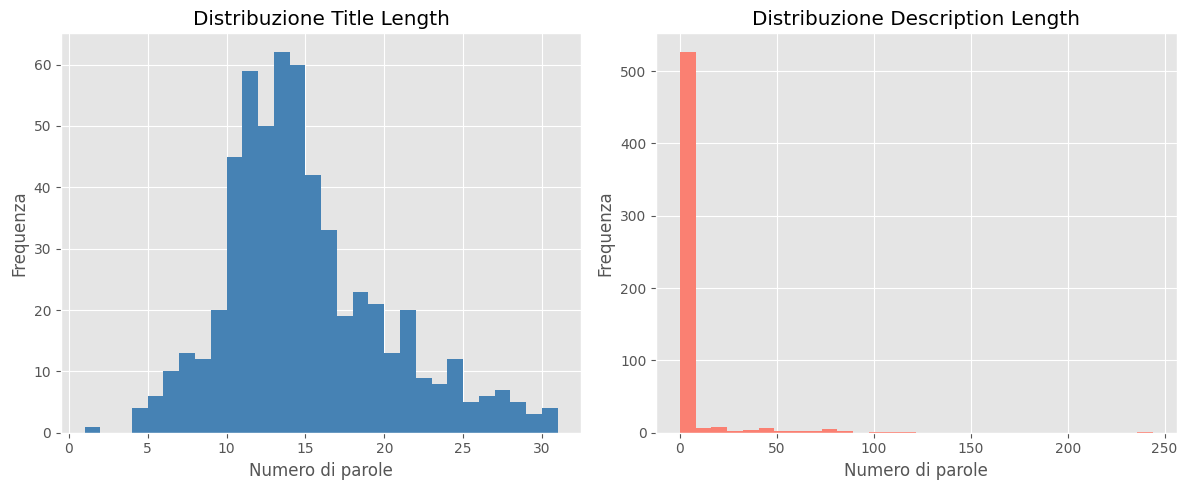

Percentuale descrizioni vuote: 91.26%
Statistiche lunghezza testo combinato:
count    572.000000
mean      18.645105
std       18.065310
min        1.000000
25%       12.000000
50%       14.000000
75%       19.000000
max      257.000000
Name: text_len, dtype: float64

Descrizione 1:
An Amazon Brand - This casual jogger features elasticized waistband with drawstring, pockets, and rib cuff. The perfect pant for all of your adventures From our hand-selected fabrics to our wide range of fits, you can rely on Goodthreads to be effortless, stylish, and crafted with care.

Descrizione 2:
Your 9-to-5 just got better! NYDJ new ankle in ponte knit is a work wear essential. Designed from a luxurious ponte knit fabric, this look accentuates maximum comfort while looking polished enough for the office. You'll also enjoy an incredible figure flattering fit, thanks to our exclusive lift tuck technology. This super slim legging silhouette features a zip fly with hook and eye closure. Non-functional ba

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
metadata_subset["title_len"].hist(bins=30, color="steelblue")
plt.title("Distribuzione Title Length")
plt.xlabel("Numero di parole")
plt.ylabel("Frequenza")

plt.subplot(1, 2, 2)
metadata_subset["desc_len"].hist(bins=30, color="salmon")
plt.title("Distribuzione Description Length")
plt.xlabel("Numero di parole")
plt.ylabel("Frequenza")

plt.tight_layout()
plt.show()

pct_empty_desc = (metadata_subset["desc_len"] == 0).mean() * 100

print(f"Percentuale descrizioni vuote: {pct_empty_desc:.2f}%")

metadata_subset["text_len"] = (
    metadata_subset["clean_title"].apply(lambda x: len(x.split())) +
    metadata_subset["clean_desc"].apply(lambda x: len(x.split()))
)

print("Statistiche lunghezza testo combinato:")
print(metadata_subset["text_len"].describe())

real_desc = metadata_subset[metadata_subset["desc_len"] > 0]["clean_desc"].head(5)

for i, desc in enumerate(real_desc, 1):
    print(f"\nDescrizione {i}:")
    print(desc)


In [37]:
#PREPARAZIONE DEL CAMPO TEXT : Pre-processamento Testuale (pulizia, tokenizzazione, normalizzazione)

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if not isinstance(text, str):
        text = str(text)

    # lowercase
    text = text.lower()

    # remove punctuation and numbers
    text = re.sub(r"[^a-z\s]", " ", text)

    # tokenize
    tokens = text.split()

    # remove stopwords + lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]

    return " ".join(tokens)

metadata_subset["clean_text"] = metadata_subset["text"].apply(clean_text)

print(metadata_subset[["text", "clean_text"]].head())


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


                                                   text  \
279   H2H Mens Active Short Sleeve Polo Lightweight ...   
354   Goodthreads Women's Heritage Fleece Basic Jogg...   
405   YAZILIND Gothic Lolita Sexy Lace Flower Cute B...   
3365  Oalka Women's Joggers High Waist Yoga Pockets ...   
3555  LIQQY Women's Plus Size Bra Comfort Contour T-...   

                                             clean_text  
279   h h men active short sleeve polo lightweight s...  
354   goodthreads woman heritage fleece basic jogger...  
405   yazilind gothic lolita sexy lace flower cute b...  
3365  oalka woman jogger high waist yoga pocket swea...  
3555  liqqy woman plus size bra comfort contour shir...  


## Generazione Embedding Testuali: TF-IDF/Transformer

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=3
)

X_tfidf = tfidf.fit_transform(metadata_subset["clean_text"])

print("Shape TF-IDF:", X_tfidf.shape)


Shape TF-IDF: (572, 1189)


In [40]:
from sentence_transformers import SentenceTransformer

# modello HuggingFace (Transformer puro) MA tramite Sentence-Transformers
model = SentenceTransformer("distilbert-base-nli-mean-tokens")

# vettorizziamo i testi
X_transformer = model.encode(
    metadata_subset["clean_text"].tolist(),
    show_progress_bar=True
)

print("Shape Transformers:", X_transformer.shape)


Batches: 100%|██████████| 18/18 [00:05<00:00,  3.17it/s]

Shape Transformers: (572, 768)


In [41]:
from sklearn.metrics.pairwise import cosine_similarity

# TF-IDF similarity matrix
sim_tfidf = cosine_similarity(X_tfidf)

# Transformer similarity matrix
sim_transformer = cosine_similarity(X_transformer)


## Predizione dei Rating con K-NN basato su Embedding

In [45]:
def recommend_tfidf(user_id, df, sim_matrix, item_to_idx, idx_to_item, N=10):
    # item visti dall’utente
    user_items = df[df["user_id"] == user_id]

    # prendiamo solo quelli con rating >= 4 (preferenze vere)
    liked_items = user_items[user_items["rating"] >= 4]["parent_asin"].unique()

    scores = {}

    for asin in liked_items:
        if asin not in item_to_idx:
            continue
        
        i = item_to_idx[asin]
        similarities = sim_matrix[i]

        # ordina item simili
        top_idx = similarities.argsort()[::-1][:50]  # top 50 simili
        for idx in top_idx:
            cand_item = idx_to_item[idx]
            if cand_item in liked_items:
                continue
                
            scores[cand_item] = scores.get(cand_item, 0) + similarities[idx]

    # ordina i candidati globalmente
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)

    return ranked[:N]

def recommend_transformer(user_id, df, sim_matrix, item_to_idx, idx_to_item, N=10):
    user_items = df[df["user_id"] == user_id]
    liked_items = user_items[user_items["rating"] >= 4]["parent_asin"].unique()

    scores = {}

    for asin in liked_items:
        if asin not in item_to_idx:
            continue

        i = item_to_idx[asin]
        similarities = sim_matrix[i]

        top_idx = similarities.argsort()[::-1][:50]
        for idx in top_idx:
            cand_item = idx_to_item[idx]
            if cand_item in liked_items:
                continue

            scores[cand_item] = scores.get(cand_item, 0) + similarities[idx]

    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)

    return ranked[:N]


In [46]:
# Costruzione dizionari indice-item
items = metadata_subset["parent_asin"].tolist()

item_to_idx = {asin: i for i, asin in enumerate(items)}
idx_to_item = {i: asin for i, asin in enumerate(items)}

# pick utente con almeno 3 like, per evitare utenti senza info
valid_users = df_final.groupby("user_id").filter(lambda x: (x["rating"] >= 4).sum() >= 3)["user_id"].unique()
user_id = np.random.choice(valid_users)

print("UTENTE SCELTO:", user_id)

top_tfidf = recommend_tfidf(
    user_id=user_id,
    df=df_final,
    sim_matrix=sim_tfidf,
    item_to_idx=item_to_idx,
    idx_to_item=idx_to_item,
    N=10
)

top_trans = recommend_transformer(
    user_id=user_id,
    df=df_final,
    sim_matrix=sim_transformer,
    item_to_idx=item_to_idx,
    idx_to_item=idx_to_item,
    N=10
)
print("\n--- TOP-10 TF-IDF ---")
for asin, score in top_tfidf:
    print(f"{asin}: {score:.4f}")

print("\n--- TOP-10 TRANSFORMER ---")
for asin, score in top_trans:
    print(f"{asin}: {score:.4f}")

tfidf_items = {asin for asin, _ in top_tfidf}
trans_items = {asin for asin, _ in top_trans}

overlap = tfidf_items.intersection(trans_items)

print("\nOVERLAP tra TF-IDF e Transformers:", len(overlap))
print("Item in comune:", overlap)


UTENTE SCELTO: AG43KQ4JCFXFQVUYEUPR2CSS2XHA

--- TOP-10 TF-IDF ---
B00KA3VEG6: 1.1662
B00LMU9NE6: 0.9942
B00OCA9ZGY: 0.9531
B00LMUA8MC: 0.9498
B00LMU8VX0: 0.9288
B00LMU7ZDM: 0.9245
B00KT13JEO: 0.8893
B00LMU7GHM: 0.8787
B00KREOWWG: 0.8717
B00KA3QT8Y: 0.8509

--- TOP-10 TRANSFORMER ---
B00LMU7ZDM: 2.4946
B00KW02QK0: 2.4912
B00LMU7WUI: 2.4726
B00KW4KR66: 2.4346
B00D08IGK0: 2.4087
B00LMUA8MC: 2.3988
B00KT13JEO: 2.3691
B00PJIV8OU: 2.3605
B00Q7TAO5E: 2.3574
B07YD5KPRT: 2.3552

OVERLAP tra TF-IDF e Transformers: 3
Item in comune: {'B00LMU7ZDM', 'B00KT13JEO', 'B00LMUA8MC'}


## Valutazione : TF-IDF vs Transformers

In [47]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

def cb_predict_rating(user_id, item_asin, df_train, sim_matrix, item_to_idx):
    """Predizione rating content-based come media pesata."""
    
    # item già valutati dall’utente
    user_rated = df_train[df_train["user_id"] == user_id]

    if len(user_rated) == 0:
        return np.nan  # impossibile predire

    if item_asin not in item_to_idx:
        return np.nan

    i = item_to_idx[item_asin]

    sims = []
    ratings = []

    for _, row in user_rated.iterrows():
        asin_j = row["parent_asin"]

        if asin_j not in item_to_idx:
            continue

        j = item_to_idx[asin_j]

        sim = sim_matrix[i, j]
        if sim > 0:  # consideriamo solo sim > 0
            sims.append(sim)
            ratings.append(row["rating"])

    if len(sims) == 0:
        return np.nan

    sims = np.array(sims)
    ratings = np.array(ratings)

    return np.sum(sims * ratings) / (np.sum(sims) + 1e-8)


def evaluate_content_based(df_test, df_train, sim_matrix, item_to_idx):
    y_true = []
    y_pred = []

    for _, row in df_test.iterrows():
        user = row["user_id"]
        asin = row["parent_asin"]
        true_rating = row["rating"]

        pred = cb_predict_rating(user, asin, df_train, sim_matrix, item_to_idx)

        if not np.isnan(pred):
            y_true.append(true_rating)
            y_pred.append(pred)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)

    return mse, rmse, mae


In [55]:
mse_tfidf, rmse_tfidf, mae_tfidf = evaluate_content_based(
    test_df, train_df, sim_tfidf, item_to_idx
)

mse_trf, rmse_trf, mae_trf = evaluate_content_based(
    test_df, train_df, sim_transformer, item_to_idx
)

print("=== TF-IDF ===")
print("MSE :", mse_tfidf)
print("RMSE:", rmse_tfidf)
print("MAE :", mae_tfidf)

print("\n=== Transformers ===")
print("MSE :", mse_trf)
print("RMSE:", rmse_trf)
print("MAE :", mae_trf)


=== TF-IDF ===
MSE : 1.4460897831708046
RMSE: 1.2025347326255507
MAE : 0.773735189740246

=== Transformers ===
MSE : 1.1175892107218586
RMSE: 1.0571609199747494
MAE : 0.7128268003504271


## Collaborative Filtering vs Content-Based

In [87]:
print("\n==========================")
print("   CONFRONTO COMPLETO     ")
print("==========================\n")

results = []

# =========================================================
# 1. RICOSTRUZIONE MATRICE DI SIMILARITÀ BEST CONFIG
# =========================================================

best_sim_name   = best_config["similarity"]
best_user_based = best_config["user_based"]
best_k          = best_config["k"]
best_shrinkage  = best_config["shrinkage"]

# matrice per similarità item-based o user-based
R_sim_base = R.T if not best_user_based else R

# calcolo matrice sim con i parametri della best config
sim_best = compute_similarity(
    R=R_sim_base,
    mu=mu,
    bu=bu,
    bi=bi,
    shrinkage=best_shrinkage,
    similarity=best_sim_name,
    user_based=best_user_based
)

print("Best similarity matrix:", sim_best.shape)



# =========================================================
# 2. KNN BASELINE
# =========================================================

mse_knn, rmse_knn, mae_knn = evaluate_knn_baseline(
    test_df=test_df,
    R=R,
    sim=sim_best,
    mu=mu,
    bu=bu,
    bi=bi,
    k=best_k,
    user_based=best_user_based
)

results.append(["KNN Baseline", mse_knn, rmse_knn, mae_knn])


# =========================================================
# 3. MF (SVD)
# =========================================================
R_hat_svd, U_svd, s_svd, Vt_svd = compute_svd_mf(R_filled, k=50)

mse_svd, rmse_svd, mae_svd = evaluate_svd(test_df, R_hat_svd)

results.append(["MF (SVD)", mse_svd, rmse_svd, mae_svd])


# =========================================================
# 4. CONTENT-BASED (TF-IDF)
# =========================================================
mse_tfidf, rmse_tfidf, mae_tfidf = evaluate_content_based(
    df_test=test_df,
    df_train=train_df,
    sim_matrix=sim_tfidf,
    item_to_idx=item_to_idx
)

results.append(["Content-Based (TF-IDF)", mse_tfidf, rmse_tfidf, mae_tfidf])


# =========================================================
# 5. CONTENT-BASED (Transformers)
# =========================================================
mse_trf, rmse_trf, mae_trf = evaluate_content_based(
    df_test=test_df,
    df_train=train_df,
    sim_matrix=sim_transformer,
    item_to_idx=item_to_idx
)

results.append(["Content-Based (Transformers)", mse_trf, rmse_trf, mae_trf])


# =========================================================
# 6. STAMPA RISULTATI IN TABELLA
# =========================================================
import pandas as pd

df_results = pd.DataFrame(
    results,
    columns=["Modello", "MSE", "RMSE", "MAE"]
)

print(df_results.to_string(index=False))



   CONFRONTO COMPLETO     

Best similarity matrix: (963, 963)
                     Modello      MSE     RMSE      MAE
                KNN Baseline 1.129058 1.062571 0.779320
                    MF (SVD) 1.051537 1.025445 0.768953
      Content-Based (TF-IDF) 1.446090 1.202535 0.773735
Content-Based (Transformers) 1.117589 1.057161 0.712827


----

# **Progetto Avanzato**

## Processing attributi testuali delle review (title text)

In [89]:
filtered_sentiment_df = df[
    (df["user_id"].isin(df_final["user_id"].unique())) &
    (df["parent_asin"].isin(df_final["parent_asin"].unique()))
].copy()

print(filtered_sentiment_df.shape)
filtered_sentiment_df.head()

(4914, 10)


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
176,5,"Cute shorts, fit well",These sorts are cute and they fit well. Stylish,[],B07QZ45PM5,B07RCK1T7P,AHATA6X6MYTC3VNBFJ3WIYVK257A,2021-08-10 19:57:23.309,0,False
179,5,Nice product. The lettering is clear,I love the inspirational statement on it. It's...,[],B07VQHJCNP,B07VQHJCNP,AHATA6X6MYTC3VNBFJ3WIYVK257A,2019-12-21 02:27:21.865,0,False
180,5,These are some nice sunglasses for the price.,These sunglasses cut the glare. They are ligh...,[],B07S8S43J7,B07S8S43J7,AHATA6X6MYTC3VNBFJ3WIYVK257A,2019-09-07 18:02:46.472,0,False
184,3,Just ok,These aren't very good quality for the price. ...,[],B07HKVLTLT,B07HKVLTLT,AHATA6X6MYTC3VNBFJ3WIYVK257A,2019-01-03 21:11:33.662,0,False
206,5,Nice Shirt,"When I first opened this shirt, I was immediat...",[],B097HQXY1V,B097HKHWL7,AHV6QCNBJNSGLATP56JAWJ3C4G2A,2022-03-26 15:34:20.099,0,False


In [90]:
filtered_sentiment_df["full_text"] = (
    filtered_sentiment_df["title"].fillna("") + " " +
    filtered_sentiment_df["text"].fillna("")
)


In [92]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text_review(text):
    if not isinstance(text, str):
        text = str(text)

    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)

    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]

    return " ".join(tokens)

filtered_sentiment_df["clean_text"] = filtered_sentiment_df["full_text"].apply(clean_text_review)

print(filtered_sentiment_df[["full_text", "clean_text"]].head())


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


                                             full_text  \
176  Cute shorts, fit well These sorts are cute and...   
179  Nice product.  The lettering is clear I love t...   
180  These are some nice sunglasses for the price. ...   
184  Just ok These aren't very good quality for the...   
206  Nice Shirt When I first opened this shirt, I w...   

                                            clean_text  
176     cute short fit well sort cute fit well stylish  
179  nice product lettering clear love inspirationa...  
180  nice sunglass price sunglass cut glare lightwe...  
184  ok good quality price would expect softer feel...  
206  nice shirt first opened shirt immediately impr...  


In [93]:
def rating_to_sentiment(r):
    if r <= 2:
        return 0   # negativo
    elif r == 3:
        return 1   # neutro
    else:
        return 2   # positivo

filtered_sentiment_df["sentiment"] = filtered_sentiment_df["rating"].apply(rating_to_sentiment)
filtered_sentiment_df["sentiment"].value_counts()


sentiment
2    3927
1     546
0     441
Name: count, dtype: int64

## Embedding campi (TFIDF e Transformers)

In [94]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=5
)

X_tfidf = tfidf.fit_transform(filtered_sentiment_df["clean_text"])
y = filtered_sentiment_df["sentiment"]

print("TF-IDF shape:", X_tfidf.shape)


TF-IDF shape: (4914, 5892)


In [95]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("distilbert-base-nli-mean-tokens")

X_trf = model.encode(
    filtered_sentiment_df["clean_text"].tolist(),
    show_progress_bar=True
)

print("Transformer shape:", X_trf.shape)


Batches: 100%|██████████| 154/154 [01:23<00:00,  1.84it/s]

Transformer shape: (4914, 768)


## Predizione del sentiment

In [98]:
from sklearn.model_selection import train_test_split

y = filtered_sentiment_df["sentiment"]

# Split per TF-IDF
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

# Split per Transformer
X_train_trf, X_test_trf, _, _ = train_test_split(
    X_trf, y, test_size=0.2, random_state=42, stratify=y
)



In [103]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

rf_tfidf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

print("Training Random Forest TF-IDF...")
rf_tfidf.fit(X_train_tfidf, y_train)

pred_tfidf = rf_tfidf.predict(X_test_tfidf)

print("\n=== RANDOM FOREST (TF-IDF) ===")
print("Accuracy:", accuracy_score(y_test, pred_tfidf))
print("F1 (macro):", f1_score(y_test, pred_tfidf, average="macro"))
print(classification_report(y_test, pred_tfidf))


Training Random Forest TF-IDF...

=== RANDOM FOREST (TF-IDF) ===
Accuracy: 0.8585961342828077
F1 (macro): 0.607128688937285
              precision    recall  f1-score   support

           0       0.96      0.52      0.68        88
           1       0.93      0.13      0.23       109
           2       0.85      1.00      0.92       786

    accuracy                           0.86       983
   macro avg       0.91      0.55      0.61       983
weighted avg       0.87      0.86      0.82       983



In [104]:
rf_trf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

print("Training Random Forest Transformer...")
rf_trf.fit(X_train_trf, y_train)

pred_trf = rf_trf.predict(X_test_trf)

print("\n=== RANDOM FOREST (TRANSFORMER) ===")
print("Accuracy:", accuracy_score(y_test, pred_trf))
print("F1 (macro):", f1_score(y_test, pred_trf, average="macro"))
print(classification_report(y_test, pred_trf))


Training Random Forest Transformer...

=== RANDOM FOREST (TRANSFORMER) ===
Accuracy: 0.8504577822990844
F1 (macro): 0.5742538386430015
              precision    recall  f1-score   support

           0       0.93      0.45      0.61        88
           1       0.92      0.11      0.20       109
           2       0.85      1.00      0.92       786

    accuracy                           0.85       983
   macro avg       0.90      0.52      0.57       983
weighted avg       0.86      0.85      0.81       983



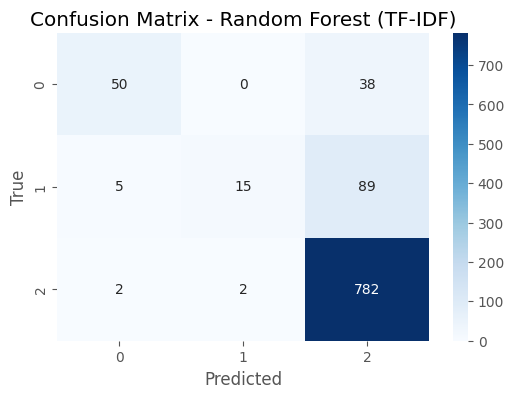

In [101]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred_tfidf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest (TF-IDF)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


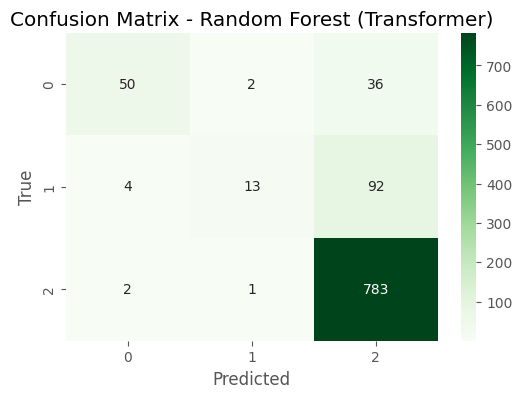

In [102]:
cm2 = confusion_matrix(y_test, pred_trf)

plt.figure(figsize=(6,4))
sns.heatmap(cm2, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Random Forest (Transformer)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [135]:
import numpy as np

# ============================================================
# 1. SELEZIONE UTENTI RAPPRESENTATIVI PER CLUSTER
# ============================================================

# cluster assegnati (da KMeans)
clusters = kmeans.labels_
num_clusters = kmeans.n_clusters

# mapping index → user_id
idx_to_user = {i: u for u, i in user_to_idx.items()}

user_representatives = {}

for c in range(num_clusters):

    # utenti del cluster c
    users_in_c = np.where(clusters == c)[0]

    # usa lo spazio PCA per rappresentazione (compatibile col clustering)
    vectors = R_pca[users_in_c]           
    centroid = kmeans.cluster_centers_[c]

    # distanza dal centroide
    dists = np.linalg.norm(vectors - centroid, axis=1)

    # utente più vicino al centro
    best_user_idx = users_in_c[np.argmin(dists)]
    best_user_id = idx_to_user[best_user_idx]

    user_representatives[c] = best_user_id

print("UTENTI RAPPRESENTATIVI PER CLUSTER:")
for c, u in user_representatives.items():
    print(f"Cluster {c}: {u}")


# ============================================================
# 2. FUNZIONE PER ESTRARRE SOLO GLI ASIN
# ============================================================

def extract_asins(recommendation_list):
    return [asin for asin, _ in recommendation_list]


# ============================================================
# 3. SENTIMENT MEDIO BASATO SULLE RECENSIONI REALI
# ============================================================

product_sentiment = (
    filtered_sentiment_df.groupby("parent_asin")["sentiment"]
    .mean()
    .to_dict()
)

def sentiment_from_reviews(asin_list, product_sentiment):
    values = [product_sentiment[a] for a in asin_list if a in product_sentiment]
    return np.mean(values) if values else None


# ============================================================
# 4. RACCOMANDAZIONI PER TUTTI I MODELLI (TF-IDF / TRF / KNN / SVD)
# ============================================================

def get_all_recommendations(user_id):

    # Content-Based TF-IDF
    rec_tfidf = recommend_tfidf(
        user_id=user_id,
        df=df_final,
        sim_matrix=sim_tfidf,
        item_to_idx=item_to_idx,
        idx_to_item=idx_to_item,
        N=10
    )

    # Content-Based Transformers
    rec_trf = recommend_transformer(
        user_id=user_id,
        df=df_final,
        sim_matrix=sim_transformer,
        item_to_idx=item_to_idx,
        idx_to_item=idx_to_item,
        N=10
    )

    # KNN Collaborative Filtering
    user_idx = user_to_idx[user_id]
    _, rec_knn = get_top_n_for_user(
        user_idx=user_idx,
        N=10,
        R_filled=R_filled,
        train_df=train_df,
        idx_to_item=idx_to_item
    )

    # Matrix Factorization (SVD)
    rec_svd = get_top_n_svd(
        user_idx=user_idx,
        N=10,
        R_hat=R_hat_svd,
        train_df=train_df,
        idx_to_item=idx_to_item
    )

    return rec_tfidf, rec_trf, rec_knn, rec_svd


# ============================================================
# 5. CALCOLO SENTIMENT DELLE RACCOMANDAZIONI
# ============================================================

def sentiment_for_user(user_id):

    rec_tfidf, rec_trf, rec_knn, rec_svd = get_all_recommendations(user_id)

    asin_tfidf = extract_asins(rec_tfidf)
    asin_trf   = extract_asins(rec_trf)
    asin_knn   = extract_asins(rec_knn)
    asin_svd   = extract_asins(rec_svd)

    return {
        "TF-IDF": sentiment_from_reviews(asin_tfidf, product_sentiment),
        "Transformer": sentiment_from_reviews(asin_trf, product_sentiment),
        "KNN": sentiment_from_reviews(asin_knn, product_sentiment),
        "SVD": sentiment_from_reviews(asin_svd, product_sentiment)
    }


UTENTI RAPPRESENTATIVI PER CLUSTER:
Cluster 0: AHWQVLWYMEGODJTTOTNBIPOBPN5Q
Cluster 1: AFUV6POK3W7N46UWBX335UF3BVUA
Cluster 2: AGH2BA6TQ43WVJL2HXW53TOBIWPA
Cluster 3: AEOIEU3ASCSHIDA5TTB4IT5O2FZA
Cluster 4: AGVTZT3WI64J4O7CKNQBAF53DYHA
Cluster 5: AFXVE3G6JGFNBJKJSJKP7DLA5WMQ


In [136]:
results = {}

for c, user_id in user_representatives.items():
    print(f"\n=== CLUSTER {c} — USER {user_id} ===")
    res = sentiment_for_user(user_id)
    results[c] = res
    print(res)



=== CLUSTER 0 — USER AHWQVLWYMEGODJTTOTNBIPOBPN5Q ===
{'TF-IDF': 1.6784126984126986, 'Transformer': 1.5849206349206348, 'KNN': 1.6749590344636787, 'SVD': 1.6664435696653186}

=== CLUSTER 1 — USER AFUV6POK3W7N46UWBX335UF3BVUA ===
{'TF-IDF': 1.575436507936508, 'Transformer': 1.8063492063492064, 'KNN': 1.591363979158097, 'SVD': 1.805888111888112}

=== CLUSTER 2 — USER AGH2BA6TQ43WVJL2HXW53TOBIWPA ===
{'TF-IDF': 1.7347727272727274, 'Transformer': 1.5865873015873015, 'KNN': 1.7250396825396828, 'SVD': 1.8419047619047622}

=== CLUSTER 3 — USER AEOIEU3ASCSHIDA5TTB4IT5O2FZA ===
{'TF-IDF': 1.7634920634920632, 'Transformer': 1.926129426129426, 'KNN': 1.7773604826546001, 'SVD': 1.8136252405002407}

=== CLUSTER 4 — USER AGVTZT3WI64J4O7CKNQBAF53DYHA ===
{'TF-IDF': 1.7239682539682541, 'Transformer': 1.6847829730182675, 'KNN': 1.6130115034448558, 'SVD': 1.8830209605209602}

=== CLUSTER 5 — USER AFXVE3G6JGFNBJKJSJKP7DLA5WMQ ===
{'TF-IDF': None, 'Transformer': None, 'KNN': 1.8881460306460305, 'SVD': 1.